<a href="https://colab.research.google.com/github/Fittx/Machine-Learning---CCMACLRL/blob/main/FORECAST_ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Project Overview

**Title:** ML-Based Monthly Booking Demand Analysis and Forecasting for Grand Imperial Business

**Business context.** Grand Imperial Business is a small short-term accommodation (staycation) business. Its booking records exist, but reviewing them by hand makes it hard to see whether demand is rising or falling, which periods are busier, and which units receive more bookings. This notebook is the **machine-learning / data-analysis component only** of the larger project (no web app, API, database, or deployment work is done here).

**Objectives**

| # | Objective | Priority |
|---|-----------|----------|
| 1 | Booking trend analysis | High |
| 2 | Overall booking demand forecasting | High |
| 3 | Unit-level demand analysis - **the 10 accommodation units only** (forecasting only if data allows) | High |
| 4 | Revenue analysis - total vs accommodation-only vs add-on/parking (descriptive; revenue *forecasting* is OFF by default because the paper forecasts daily booking count only) | High |
| 5 | Occupancy analysis / forecasting | Conditional – needs inventory information |

**Business scope.** Only **10 accommodation units** are analysed (Shore Residence, Pasay: ELEANOR, GABRIEL, DIANA, ELIZABETH, MARGARET, JULIANA, VICTORIA, MATILDA; Fame Residence, Mandaluyong: LEA, ALICIA). Parking, decor, airport pick-up, massage and similar rows are add-ons / billing rows and are kept out of demand, unit, occupancy and forecasting work. Check-in dates outside the valid window (default 2026) are logged and excluded, and a month with no valid data is reported as missing - never as zero.

**Design principle – the data decides.** The notebook measures how much history it has been given and only runs a forecasting model when that history is long enough. When it is not, the corresponding section prints a clear "skipped" explanation instead of forcing a model. Nothing is simulated or back-filled.

**Course rules that shape the modelling** (from the *Final Group Project Requirements*)

* Exactly **three permitted traditional regression algorithms** are compared: **Ridge Regression, Random Forest Regressor, Gradient Boosting Regressor**. Simple baselines are reported for context but are *not* counted as one of the three.
* Neural networks, deep learning, AutoML, etc. are not used.
* Time-ordered data uses a **chronological 80 % / 20 % split** (never random shuffling). Tuning happens only inside the training part, with **time-ordered 5-fold cross-validation**. The test set is used **once**, for the selected model.
* ARIMA / SARIMA / exponential smoothing are **not** in the permitted-algorithm list, so they are deliberately left out of the three-model comparison. (They could be added as an extra reference only with instructor approval.)
* Random seeds are fixed for reproducibility.

**How to use this notebook with January to December data**

1. Upload **one workbook per month** (e.g. `D-JAN26.xlsx` … `D-DEC26.xlsx`) *or* a single workbook that already contains several months. You may upload several files at once.
2. Each workbook must contain the cleaned sheet **`ML_Data`** (the notebook finds it automatically).
3. Run all cells. The business charts are: a **line chart** of monthly booking demand (actual vs forecast, Section 12), a **bar chart** of predicted demand per condo unit (Section 13.1) and a **line chart** of monthly occupancy (actual vs forecast, Section 14). Add another month later and simply re-run – the feasibility gates in Section 9 re-evaluate automatically.

`Booking ID` restarts at `B0001` in every monthly file. That is fully supported: the notebook never uses Booking ID on its own. It builds a unique `Record ID` (file name + Booking ID) for every row, checks that no two rows share one, and prints a per-file report (Section 3) so you can see each month was loaded separately.

**Privacy.** Only the ML fields listed in Section 3 are kept. Guest names and other raw/personal columns (if a workbook contains them) are dropped on load and never displayed or used as features.

# 2. Imports and Environment Setup

In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("Environment ready. Random seed =", SEED)

Environment ready. Random seed = 42


### 2.1 Configuration (all thresholds in one place)

These values are **project-defined rules of thumb**, not universal laws. They exist so the notebook can refuse to train a model that the data cannot support. They can be adjusted, but lowering them makes results less trustworthy.

In [ ]:
# ---- Project scope: VALID calendar window for check-in dates ----------------
# Check-in dates outside this window (e.g. the 1970 "epoch" dates produced when Excel date serials are mis-read)
# are logged and EXCLUDED from every calendar-based analysis and from forecasting.
VALID_START = pd.Timestamp("2026-01-01")   # project window; alternative configurable range: 2020-01-01 ...
VALID_END   = pd.Timestamp("2026-12-31")   #                                                 ... 2035-12-31

# ---- Forecasting set-up ---------------------------------------------------
FORECAST_MONTHS_AHEAD = 1    # whole calendar months to forecast after the last month in the data (1 = next month)
HORIZON_DAYS   = None   # set automatically in Section 9: days from the last booking date to the end of the forecast month(s)
TEST_FRACTION  = 0.20   # chronological hold-out (course rule: 80/20)
CV_SPLITS      = 5      # time-ordered cross-validation folds inside the training set
WEEKEND_NIGHTS = {4, 5} # Monday=0 ... Sunday=6 -> Friday & Saturday. ANALYTICAL ASSUMPTION: confirm with the business.

# ---- Feasibility gates ("does the data contain enough history?") ----------
MIN_DAYS_DAILY_ML     = 240  # ~8 months of calendar span before a daily-level ML model is trained
MIN_USABLE_ROWS       = 120  # rows left after lag/rolling warm-up
MIN_MONTHS_TREND_STAT = 6    # months needed before a trend statistic is reported
MIN_MONTHS_SEASONAL   = 24   # months needed before month/week-of-year seasonality may be learned or claimed
MIN_UNIT_WEEKS        = 40   # complete weeks needed for the unit-level model
MIN_UNIT_BOOKINGS     = 20   # bookings a unit needs to be included in the unit-level model
UNIT_HORIZON_WEEKS    = 4
UNIT_SHARE_DAYS       = 90   # unit bar chart fallback: split the overall forecast by each unit's share of the last N days
ALLOW_MISSING_MONTHS  = False # DEFAULT False: a month with no valid data blocks forecasting. True = EXPERIMENTAL, UNRELIABLE run (missing days stay NaN, never zero-filled)

# ---- Data-quality gates (added) ------------------------------------------------
UNRECOVERED_FILE_SHARE = 0.5   # a workbook with fewer than this share of rows holding a VALID check-in date is flagged "unrecovered"
THIN_MONTH_RATIO       = 0.25  # a month (other than the last) with < 25 % of the median monthly bookings is flagged as probably incomplete/missing
ENABLE_REVENUE_FORECAST = False  # the ML paper forecasts daily BOOKING COUNT only (Section 2.5 Limitations); revenue forecasting is OFF by default
USE_MONTH_WEEK_FEATURES = None   # None = automatic (month/week-of-year features only with >= MIN_MONTHS_SEASONAL months). True/False forces it.
                                 # The paper lists month and week-of-year; with < 24 months they only memorise the single year, so the default keeps them off.

# ---- Occupancy inventory ----------------------------------------------------
# Best: fill in the real inventory (unit: (first date available, last date available or None if still available)):
# INVENTORY = {"MARGARET": ("2026-01-01", None), "ELEANOR": ("2026-03-15", None)}
INVENTORY = None
# If INVENTORY is None and this is True, occupancy is ESTIMATED by assuming each of the 10 ACCOMMODATION units can be sold every
# day from the first day of the month of its first booking. It is labelled "estimated" everywhere. Set False to switch off.
ASSUME_UNITS_AVAILABLE = True


### 2.2 Business scope: accommodation units only

Only **10 units are real accommodation units**. Parking, decor, airport pick-up, massage and similar rows are **add-ons / service / billing rows**: they are kept in `df_non_accom` for separate revenue reporting but are excluded from unit demand, occupancy, unit-level forecasting and the unit bar chart.

| Location | Category | Units |
|---|---|---|
| Shore Residence (Pasay) | Family Suites | ELEANOR, GABRIEL, DIANA |
| Shore Residence (Pasay) | Direct To Pool | ELIZABETH, MARGARET, JULIANA, VICTORIA, MATILDA |
| Fame Residence (Mandaluyong) | *(category not given)* | LEA, ALICIA |

Unit labels are cleaned (punctuation/parentheses stripped, upper-cased) and matched to the 10 canonical names. Transfer-style labels keep the original in `Unit ID Original`, use the **primary (first) canonical unit** as `Unit ID`, and get a `Unit Note` for manual review. Anything else is excluded - nothing is guessed.

In [ ]:
import re, difflib

# ---- The 10 real accommodation units -------------------------------------------------------------
ACCOMMODATION_UNITS = ["ELEANOR", "GABRIEL", "DIANA", "ELIZABETH", "MARGARET", "JULIANA", "VICTORIA", "MATILDA", "LEA", "ALICIA"]

_SHORE = ["ELEANOR", "GABRIEL", "DIANA", "ELIZABETH", "MARGARET", "JULIANA", "VICTORIA", "MATILDA"]
UNIT_LOCATION = {**{u: "Shore Residence (Pasay)" for u in _SHORE},
                 **{u: "Fame Residence (Mandaluyong)" for u in ["LEA", "ALICIA"]}}
UNIT_CATEGORY = {**{u: "Family Suites"  for u in ["ELEANOR", "GABRIEL", "DIANA"]},
                 **{u: "Direct To Pool" for u in ["ELIZABETH", "MARGARET", "JULIANA", "VICTORIA", "MATILDA"]},
                 **{u: "Not specified"  for u in ["LEA", "ALICIA"]}}      # no category was given for the Fame Residence units
assert set(UNIT_LOCATION) == set(UNIT_CATEGORY) == set(ACCOMMODATION_UNITS) and len(ACCOMMODATION_UNITS) == 10

# Token-level aliases for OBVIOUS typos / glued prefixes seen in the data. Add to this dict only after the business confirms a mapping.
UNIT_ALIASES = {"TJULIANA": "JULIANA"}      # e.g. "VICTORIA(TJULIANA)"

# Rows matching any of these are add-ons / services / billing lines, never accommodation units (matched on the cleaned, upper-case label).
EXCLUDED_UNIT_PATTERNS = [r"PARKING", r"DECOR", r"AIRPORT", r"PICK\s*UP", r"MASSAGE", r"SHUTTLE",
                          r"VOUCHER", r"EXTRA\s*HOUR", r"\bG\s?\d{2,4}\b"]

def normalize_unit(raw):
    """Return a dict: clean, include, cls, reason, note.  Never guesses: anything unclear is excluded and explained."""
    if pd.isna(raw) or str(raw).strip() == "":
        return dict(clean=np.nan, include=False, cls="missing", reason="Missing Unit ID", note="")
    label = re.sub(r"[^A-Z0-9]+", " ", str(raw).upper()).strip()          # strip parentheses / punctuation / junk
    for pat in EXCLUDED_UNIT_PATTERNS:
        if re.search(pat, label):
            return dict(clean=label, include=False, cls="add-on/service",
                        reason=f"Add-on / service / billing row (matches '{pat}')", note="")
    toks = [UNIT_ALIASES.get(t, t) for t in label.split()]
    found = []
    for t in toks:
        if t in ACCOMMODATION_UNITS and t not in found:
            found.append(t)
    if not found:
        hint = ""
        for t in label.split():
            close = difflib.get_close_matches(t, ACCOMMODATION_UNITS, n=1, cutoff=0.8)
            if close:
                hint = f" - possible typo of {close[0]}; add it to UNIT_ALIASES if the business confirms"; break
        return dict(clean=label, include=False, cls="out-of-scope", reason="Not one of the 10 accommodation units" + hint, note="")
    primary = found[0]
    if len(found) > 1:
        return dict(clean=primary, include=True, cls="accommodation",
                    reason=f"Multi-unit / transfer-style label: primary unit {primary} used",
                    note=f"Original '{str(raw).strip()}' also names {', '.join(found[1:])} - REVIEW MANUALLY")
    if label == primary:
        reason = "Exact match" if str(raw).strip().upper() == primary else "Punctuation / case cleaned"
    elif any(UNIT_ALIASES.get(t) == primary for t in label.split()):
        reason = "Typo / prefix mapped via UNIT_ALIASES"
    else:
        reason = "Canonical unit found inside a longer label (extra text dropped)"
    return dict(clean=primary, include=True, cls="accommodation", reason=reason, note="")

print("Accommodation units (" + str(len(ACCOMMODATION_UNITS)) + "):", ", ".join(ACCOMMODATION_UNITS))


Accommodation units (10): ELEANOR, GABRIEL, DIANA, ELIZABETH, MARGARET, JULIANA, VICTORIA, MATILDA, LEA, ALICIA


# 3. Load Dataset

The loader:

1. asks for the Excel file(s) (Colab upload dialog; outside Colab it uses `.xlsx` files in the working folder),
2. finds the **cleaned ML sheet** in each workbook (prefers `ML_Data`; raw sheets are never chosen because they lack the required columns),
3. keeps **only** the expected ML columns (this silently drops guest names and other raw columns),
4. stacks all files and creates a unique `Record ID`.

In [ ]:
EXPECTED_COLS = ["Booking ID","Source","Unit ID","Check-In Date","Check-Out Date","Nights","Pax",
                 "Extra Hours","Pool Voucher","Parking","Setup Decor","Massage","Airport Shuttle",
                 "Total Bill","Downpayment","Remaining Balance","Status"]
REQUIRED_COLS = ["Unit ID","Check-In Date","Check-Out Date","Nights","Pax","Total Bill"]
ADDON_COLS    = ["Extra Hours","Pool Voucher","Parking","Setup Decor","Massage","Airport Shuttle"]

# Header matching ignores case, spaces and hyphens, so "Check-in date " in one month's file is still read as
# "Check-In Date" (monthly files are often typed by hand and rarely match perfectly).
def _canon(name):
    return "".join(ch for ch in str(name).lower() if ch.isalnum())
CANON_MAP = {_canon(c): c for c in EXPECTED_COLS}

def tidy_headers(frame):
    return frame.rename(columns={c: CANON_MAP.get(_canon(c), str(c).strip()) for c in frame.columns})

def get_input_files():
    try:
        from google.colab import files
        print("Upload one or more monthly workbooks (e.g. D-JAN26.xlsx ... D-DEC26.xlsx), or one combined workbook.")
        paths = list(files.upload().keys())
    except ImportError:
        paths = []
    if not paths:
        paths = sorted(glob.glob("*.xlsx"))
        print("No upload detected - using .xlsx files found in the working folder.")
    paths = [p for p in paths if p.lower().endswith((".xlsx", ".xlsm"))]
    if not paths:
        raise FileNotFoundError("No Excel workbook found. Upload the monthly .xlsx file(s) and re-run this cell.")
    return paths

def pick_sheet(path):
    xl = pd.ExcelFile(path)
    ok = [n for n in xl.sheet_names
          if all(c in tidy_headers(pd.read_excel(xl, sheet_name=n, nrows=0)).columns for c in REQUIRED_COLS)]
    if not ok:
        raise ValueError(f"{os.path.basename(path)}: no sheet contains the required columns {REQUIRED_COLS}")
    def rank(n):
        k = n.lower().replace(" ", "_")
        return 0 if k == "ml_data" else 1 if "ml" in k else 2 if "clean" in k else 3
    return sorted(ok, key=rank)[0]

# ---- robust date parsing -------------------------------------------------------------------------
# pd.to_datetime() reads a plain NUMBER such as 46205 as 46,205 *nanoseconds* after 1970 -> "1970-01-01".
# That is the usual cause of 1970 dates when a workbook stores dates as Excel serial numbers instead of date cells.
# We therefore parse each CELL VALUE by its own type. Nothing is inferred from the file name.
import datetime as _dtm
from collections import Counter
EXCEL_EPOCH = pd.Timestamp("1899-12-30")
SERIAL_MIN, SERIAL_MAX = 36526, 73415        # Excel serial numbers for 2000-01-01 ... 2100-12-31

def _parse_one(v):
    if v is None or (not isinstance(v, (list, tuple)) and pd.isna(v)):
        return pd.NaT, "blank"
    if isinstance(v, (pd.Timestamp, _dtm.datetime, _dtm.date, np.datetime64)):
        return pd.Timestamp(v), "date cell"
    num = None
    if isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, (bool, np.bool_)):
        num = float(v)
    else:
        s = str(v).strip()
        if s == "":
            return pd.NaT, "blank"
        if re.fullmatch(r"\d+(\.\d+)?", s):
            num = float(s)
        else:
            ts = pd.to_datetime(s, errors="coerce")
            return (ts, "text date") if pd.notna(ts) else (pd.NaT, "unparseable text")
    if SERIAL_MIN <= num <= SERIAL_MAX:
        return EXCEL_EPOCH + pd.to_timedelta(num, unit="D"), "excel serial"
    return pd.NaT, "number that is not a date serial"

def parse_excel_dates(series):
    out, how = [], Counter()
    for v in series:
        ts, kind = _parse_one(v); out.append(ts); how[kind] += 1
    return pd.to_datetime(pd.Series(out, index=series.index)), how

date_methods, raw_date_samples = {}, {}

frames, sheet_used, dropped_log = [], {}, {}
for p in get_input_files():
    fname = os.path.basename(p); stem = os.path.splitext(fname)[0]
    sheet = pick_sheet(p)
    raw = tidy_headers(pd.read_excel(p, sheet_name=sheet))
    dropped_log[fname] = [c for c in raw.columns if c not in EXPECTED_COLS]
    sheet_used[fname] = sheet
    part = raw[[c for c in EXPECTED_COLS if c in raw.columns]].copy()
    for c in EXPECTED_COLS:
        if c not in part.columns:
            part[c] = np.nan
    part = part.dropna(how="all").reset_index(drop=True)          # ignore blank rows left in the sheet
    raw_date_samples[fname] = [repr(v) for v in part["Check-In Date"].head(5).tolist()]
    part["Check-In Date"], date_methods[fname] = parse_excel_dates(part["Check-In Date"])     # cell-value based; see parser above
    part["Check-Out Date"], _ = parse_excel_dates(part["Check-Out Date"])

    # --- Booking ID: every monthly file restarts at B0001, so it is only unique INSIDE one file ---
    bid = part["Booking ID"]
    if bid.isna().all():
        bid = pd.Series([f"R{i+1:04d}" for i in range(len(part))], index=part.index)
    bid = bid.where(bid.isna(), bid.astype(str).str.strip().str.upper())
    part["Booking ID"] = bid
    # Record ID = file name + Booking ID (+ "#2" if an ID is repeated inside the same file, + row number if blank)
    rid = bid.where(bid.notna(), pd.Series([f"ROW{j+1:04d}" for j in range(len(part))], index=part.index)).astype(str)
    rep = rid.groupby(rid).cumcount()
    rid = rid.where(rep == 0, rid + "#" + (rep + 1).astype(str))
    part["Record ID"] = stem + "|" + rid
    part["Source File"] = fname
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
if not df["Record ID"].is_unique:
    raise ValueError("Record ID is not unique - two uploaded files may have the same name. Rename one and re-run.")

# ---- type conversion (values are preserved, only the dtype is standardised) ----
for c in ["Check-In Date", "Check-Out Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")
for c in ["Nights","Pax","Total Bill","Downpayment","Remaining Balance"] + ADDON_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in ["Source", "Unit ID", "Status"]:
    df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())
# ---- unit normalisation: keep the original label, then map to the 10 accommodation units (Section 2.2) ----
df["Unit ID Original"] = df["Unit ID"]
_um = {o: normalize_unit(o) for o in df["Unit ID Original"].dropna().unique()}
_miss = normalize_unit(np.nan)
def _ucol(k): return df["Unit ID Original"].map(lambda o: _um.get(o, _miss)[k])
df["Unit ID"]       = _ucol("clean")
df["Unit Include"]  = _ucol("include").astype(bool)
df["Unit Class"]    = _ucol("cls")
df["Unit Reason"]   = _ucol("reason")
df["Unit Note"]     = _ucol("note")
df["Unit Location"] = df["Unit ID"].where(df["Unit Include"]).map(UNIT_LOCATION)
df["Unit Category"] = df["Unit ID"].where(df["Unit Include"]).map(UNIT_CATEGORY)
df[ADDON_COLS] = df[ADDON_COLS].fillna(0)   # data dictionary: blank add-on = 0

# ---- per-file report: proves each month was loaded on its own ----
id_files = df.dropna(subset=["Booking ID"]).groupby("Booking ID")["Source File"].nunique()
shared_ids = id_files[id_files > 1]
file_log = []
for f, g in df.groupby("Source File", sort=False):
    _ok = g["Check-In Date"].between(VALID_START, VALID_END)
    mc = g.loc[_ok, "Check-In Date"].dt.to_period("M").value_counts()
    file_log.append({"File": f, "Sheet used": sheet_used[f], "Rows": len(g),
                     "First -> last Booking ID": f"{g['Booking ID'].iloc[0]} -> {g['Booking ID'].iloc[-1]}",
                     "Main check-in month": str(mc.index[0]) if len(mc) else "n/a (no valid date)",
                     "Rows with missing / invalid check-in": int((~_ok).sum()),
                     "Rows whose Booking ID is also used in another file": int(g["Booking ID"].isin(shared_ids.index).sum()),
                     "Columns dropped (not ML fields)": len(dropped_log[f])})
file_log.sort(key=lambda r: r["Main check-in month"])
print("Workbooks loaded:")
display(pd.DataFrame(file_log))
print(f"Total rows: {len(df)} | unique Record IDs: {df['Record ID'].nunique()} (must be equal)")
if len(shared_ids):
    print(f"Booking IDs such as {shared_ids.index[0]} appear in more than one file ({len(shared_ids)} distinct IDs). "
          "This is expected because each monthly file restarts numbering. Rows are kept apart by Record ID, "
          "and Booking ID alone is never used to match, join or de-duplicate records.")
mm = df[df["Check-In Date"].between(VALID_START, VALID_END)].assign(M=lambda x: x["Check-In Date"].dt.to_period("M")).groupby("M")["Source File"].nunique()
mm = mm[mm > 1]
if len(mm):
    print(f"Notice: check-in month(s) {', '.join(map(str, mm.index))} appear in more than one file. This is fine if a file holds a few "
          "bookings from a neighbouring month; if a whole month was uploaded twice, exact repeats are removed in Section 4.")


Upload one or more monthly workbooks (e.g. D-JAN26.xlsx ... D-DEC26.xlsx), or one combined workbook.


Saving D-SEPT26 (2).xlsx to D-SEPT26 (2) (1).xlsx
Saving D-MAY26.xlsx to D-MAY26 (1).xlsx
Saving D-MAR26.xlsx to D-MAR26 (1).xlsx
Saving D-JUN26.xlsx to D-JUN26 (1).xlsx
Saving D-JUL26.xlsx to D-JUL26 (1).xlsx
Saving D-JAN26.xlsx to D-JAN26 (1).xlsx
Saving D-FEB26.xlsx to D-FEB26 (1).xlsx
Saving D-AUG26.xlsx to D-AUG26 (1).xlsx
Saving D-APR26.xlsx to D-APR26 (1).xlsx
Workbooks loaded:


,File,Sheet used,Rows,First -> last Booking ID,Main check-in month,Rows with missing / invalid check-in,Rows whose Booking ID is also used in another file,Columns dropped (not ML fields)
0,D-JAN26 (1).xlsx,ML_Data,96,B0001 -> B0096,2026-01,1,96,0
1,D-FEB26 (1).xlsx,ML_Data,87,B0001 -> B0087,2026-02,1,87,0
2,D-MAR26 (1).xlsx,ML_Data,102,B0001 -> B0102,2026-03,2,102,0
3,D-APR26 (1).xlsx,ML_Data,160,B0001 -> B0160,2026-04,2,153,0
4,D-MAY26 (1).xlsx,ML_Data,153,B0001 -> B0153,2026-05,0,153,0
5,D-JUN26 (1).xlsx,ML_Data,119,B0001 -> B0119,2026-06,1,119,0
6,D-JUL26 (1).xlsx,ML_Data,76,B0001 -> B0076,2026-07,0,76,0
7,D-AUG26 (1).xlsx,ML_Data,90,B0001 -> B0090,2026-08,0,90,0
8,D-SEPT26 (2) (1).xlsx,ML_Data,74,B0001 -> B0074,2026-09,1,74,0


Total rows: 957 | unique Record IDs: 957 (must be equal)
Booking IDs such as B0001 appear in more than one file (153 distinct IDs). This is expected because each monthly file restarts numbering. Rows are kept apart by Record ID, and Booking ID alone is never used to match, join or de-duplicate records.
Notice: check-in month(s) 2026-02, 2026-03, 2026-04, 2026-06 appear in more than one file. This is fine if a file holds a few bookings from a neighbouring month; if a whole month was uploaded twice, exact repeats are removed in Section 4.


### 3.1 Audit: unit mapping and check-in dates

Two audits before any analysis: (A) how every original `Unit ID` label was mapped, and (B) how many check-in dates in each workbook are valid for this project (`VALID_START` ... `VALID_END`). A workbook whose dates cannot be recovered is flagged here and blocks forecasting in Section 9 - the notebook never invents dates and never reads them from the file name.

In [ ]:
# ---- A) unit mapping audit ---------------------------------------------------------------------------
um = (df.assign(_o=df["Unit ID Original"].fillna("(blank)"))
        .groupby("_o", sort=False)
        .agg(**{"Clean Unit ID": ("Unit ID", "first"), "Included?": ("Unit Include", "first"), "Reason": ("Unit Reason", "first"),
                "Location": ("Unit Location", "first"), "Category": ("Unit Category", "first"),
                "Rows": ("Record ID", "count"), "Unit Note": ("Unit Note", "first")})
        .rename_axis("Original Unit ID").reset_index())
um["Included?"] = um["Included?"].map({True: "YES", False: "no"})
um = um.sort_values(["Included?", "Original Unit ID"], ascending=[False, True]).reset_index(drop=True)
print(f"{df['Unit ID Original'].nunique()} distinct original Unit ID labels -> {df.loc[df['Unit Include'], 'Unit ID'].nunique()} accommodation units "
      f"(rows: {int(df['Unit Include'].sum())} accommodation, {int((~df['Unit Include']).sum())} excluded).")
with pd.option_context("display.max_rows", 200, "display.max_colwidth", 90):
    display(um)
absent = [u for u in ACCOMMODATION_UNITS if u not in set(df.loc[df["Unit Include"], "Unit ID"])]
print("Accommodation units with NO rows in the loaded data:", absent or "none")
if (um["Unit Note"].fillna("") != "").any():
    print("\nMulti-unit / transfer-style labels needing manual review:"); display(um[um["Unit Note"].fillna("") != ""][["Original Unit ID", "Clean Unit ID", "Unit Note"]])

# ---- B) date audit per workbook ------------------------------------------------------------------------
rows, unrecovered_files = [], []
for f, g in df.groupby("Source File", sort=False):
    ci = g["Check-In Date"]; ok = ci.between(VALID_START, VALID_END)
    share = ok.mean() if len(g) else 0.0
    rows.append({"File": f, "Rows": len(g), "Valid check-in": int(ok.sum()), "Outside valid range (e.g. 1970)": int((ci.notna() & ~ok).sum()),
                 "Missing / unparseable": int(ci.isna().sum()), "Valid share": f"{share:.0%}",
                 "How check-in cells were read": ", ".join(f"{k}: {v}" for k, v in date_methods[f].items())})
    if share < UNRECOVERED_FILE_SHARE:
        unrecovered_files.append(f)
date_audit = pd.DataFrame(rows)
display(date_audit)
recovered = [f for f in date_methods if date_methods[f].get("excel serial", 0) > 0]
for f in recovered:
    print(f"RECOVERED: {f} stored {date_methods[f]['excel serial']} check-in value(s) as Excel serial numbers; they were converted with Excel's own 1899-12-30 epoch (cell values only).")
for f in unrecovered_files:
    print("\n" + "!" * 100)
    print(f"INVALID DATES NOT RECOVERABLE: {f} - fewer than {UNRECOVERED_FILE_SHARE:.0%} of its rows have a check-in date inside {VALID_START.date()} ... {VALID_END.date()}.")
    print("First raw check-in cell values found in the file:", raw_date_samples[f])
    print("Its rows are excluded from all calendar analyses and forecasting. Dates are NOT inferred from the file name.")
    print("ACTION: upload a corrected workbook for this month (check-in / check-out must be real dates in the valid range) and re-run.")
    print("!" * 100)
if not unrecovered_files:
    print("\nAll workbooks have mostly valid check-in dates.")


42 distinct original Unit ID labels -> 10 accommodation units (rows: 894 accommodation, 63 excluded).


,Original Unit ID,Clean Unit ID,Included?,Reason,Location,Category,Rows,Unit Note
0,(blank),None,no,Missing Unit ID,None,None,1,
1,302 PARKING,302 PARKING,no,Add-on / service / billing row (matches 'PARKING'),None,None,1,
2,302.0,302 0,no,Not one of the 10 accommodation units,None,None,1,
3,356 PARKING,356 PARKING,no,Add-on / service / billing row (matches 'PARKING'),None,None,1,
4,356.0,356 0,no,Not one of the 10 accommodation units,None,None,3,
5,AIRPORT PICK UP,AIRPORT PICK UP,no,Add-on / service / billing row (matches 'AIRPORT'),None,None,1,
6,ANASTASIA,ANASTASIA,no,Not one of the 10 accommodation units,None,None,6,
7,BEDROOM DECOR,BEDROOM DECOR,no,Add-on / service / billing row (matches 'DECOR'),None,None,1,
8,CALIX,CALIX,no,Not one of the 10 accommodation units,None,None,8,
9,G302,G302,no,"Add-on / service / billing row (matches '\bG\s?\d{2,4}\b')",None,None,1,


Accommodation units with NO rows in the loaded data: none

Multi-unit / transfer-style labels needing manual review:


,Original Unit ID,Clean Unit ID,Unit Note
35,GABRIEL (TRANSFER TO DIANA),GABRIEL,Original 'GABRIEL (TRANSFER TO DIANA)' also na...
41,VICTORIA(TJULIANA),VICTORIA,Original 'VICTORIA(TJULIANA)' also names JULIA...


,File,Rows,Valid check-in,Outside valid range (e.g. 1970),Missing / unparseable,Valid share,How check-in cells were read
0,D-SEPT26 (2) (1).xlsx,74,73,0,1,99%,"date cell: 73, blank: 1"
1,D-MAY26 (1).xlsx,153,153,0,0,100%,date cell: 153
2,D-MAR26 (1).xlsx,102,100,0,2,98%,"date cell: 100, blank: 2"
3,D-JUN26 (1).xlsx,119,118,0,1,99%,"date cell: 118, blank: 1"
4,D-JUL26 (1).xlsx,76,76,0,0,100%,date cell: 76
5,D-JAN26 (1).xlsx,96,95,0,1,99%,"date cell: 95, blank: 1"
6,D-FEB26 (1).xlsx,87,86,0,1,99%,"date cell: 86, blank: 1"
7,D-AUG26 (1).xlsx,90,90,0,0,100%,"date cell: 89, excel serial: 1"
8,D-APR26 (1).xlsx,160,158,0,2,99%,"date cell: 158, blank: 2"


RECOVERED: D-AUG26 (1).xlsx stored 1 check-in value(s) as Excel serial numbers; they were converted with Excel's own 1899-12-30 epoch (cell values only).

All workbooks have mostly valid check-in dates.


In [ ]:
print("Dataset shape (all loaded rows):", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:"); display(df.dtypes.to_frame("dtype").T)
print("\nFirst rows:"); display(df.head())
print("\nNumeric summary statistics:"); display(df.describe().T)
print("\nCategorical summary:"); display(df[["Source", "Unit ID", "Status"]].describe().T)
print("\nMissing values per column (only columns with gaps):")
mv = df.isna().sum(); display(mv[mv > 0].to_frame("missing").T if mv.sum() else "No missing values")
print("\nOriginal Unit ID labels:", df["Unit ID Original"].nunique(), "| accommodation units after cleaning:",
      sorted(df.loc[df["Unit Include"], "Unit ID"].unique()))
_v = df.loc[df["Check-In Date"].between(VALID_START, VALID_END), "Check-In Date"]
print(f"Check-in range of VALID dates ({VALID_START.date()} .. {VALID_END.date()}): {_v.min().date()} to {_v.max().date()}  "
      f"| rows with a missing or out-of-range check-in: {len(df) - len(_v)} (logged in Section 3.1 / 4)")

# 4. Dataset Validation

The workbook is already cleaned, so this section **validates** rather than re-cleans. Every issue found is logged with the action taken. Nothing is silently changed.

**Decisions that affect later sections (stated explicitly so they can be challenged):**

* **Check-in date places a booking in time.** Demand is counted on the day the stay *starts*. Booking-creation dates are not in the ML sheet, so "when the customer decided to book" cannot be analysed.
* **`Nights` is treated as the authoritative stay length** (the price is based on nights). The calendar of occupied nights is `Check-In + Nights`. If `Check-Out − Check-In` disagrees with `Nights`, the record is flagged for the business to verify.
* Rows with a **missing date** stay in non-time analyses (unit, pax, revenue totals) but are excluded from anything placed on a calendar.
* Suspected **duplicate stays** (same unit, dates, nights, pax, bill) are removed once; this also protects against uploading the same file twice.
* **Scope and dates (added).** Only the 10 accommodation units feed demand analysis; rows with a missing or out-of-window check-in date (e.g. 1970) are excluded from every calendar-based analysis and counted in the exclusions table in Section 4.1.

In [ ]:
issues = []
def log_issue(check, n, action, detail=""):
    issues.append({"Check": check, "Records": int(n), "Action taken": action, "Detail": detail})

# 1) duplicates ---------------------------------------------------------------
key = ["Unit ID","Check-In Date","Check-Out Date","Nights","Pax","Total Bill"]
dup_stay = df.duplicated(subset=key, keep="first") & df["Check-In Date"].notna()
log_issue("Duplicate stays (same unit, dates, nights, pax, bill)", dup_stay.sum(),
          "Removed (first occurrence kept)" if dup_stay.any() else "None found",
          ", ".join(df.loc[dup_stay, "Record ID"].head(5)))
df = df.loc[~dup_stay].reset_index(drop=True)
date_in_range = df["Check-In Date"].between(VALID_START, VALID_END)     # valid project window (Section 2.1)
dup_id = df["Booking ID"].notna() & df.duplicated(subset=["Source File", "Booking ID"], keep=False)
log_issue("Repeated Booking ID inside one file", dup_id.sum(), "None found" if not dup_id.any() else "Kept; Record ID made unique with a #n suffix - review manually")
log_issue("Booking IDs reused across monthly files (distinct IDs)", len(shared_ids),
          "Expected - each monthly file restarts at B0001; rows kept apart by Record ID" if len(shared_ids) else "None found",
          ", ".join(map(str, shared_ids.index[:5])))

# 2) missing values -----------------------------------------------------------
miss_dates = df["Check-In Date"].isna() | df["Check-Out Date"].isna()
log_issue("Missing check-in / check-out date", miss_dates.sum(),
          "Kept for non-time analyses; excluded from calendar-based analyses" if miss_dates.any() else "None",
          ", ".join(df.loc[miss_dates, "Record ID"].head(5)))
for c in ["Unit ID", "Nights", "Pax", "Total Bill"]:
    log_issue(f"Missing {c}", df[c].isna().sum(), "None found" if not df[c].isna().any() else ("Excluded from unit / demand analysis (kept in df_non_accom)" if c == "Unit ID" else "Excluded from analyses that need it"))

# 3) impossible / negative values ---------------------------------------------
num_cols = ["Nights","Pax","Total Bill","Downpayment","Remaining Balance"] + ADDON_COLS
neg = (df[num_cols] < 0).any(axis=1)
log_issue("Negative numeric values", neg.sum(), "None found" if not neg.any() else "Review manually")
bad_n = (df["Nights"] < 1) | (df["Pax"] < 1)
log_issue("Nights < 1 or Pax < 1", bad_n.sum(), "None found" if not bad_n.any() else "Excluded from calendar analyses")
out_of_range = df["Check-In Date"].notna() & ~date_in_range
log_issue(f"Check-in date outside {VALID_START.date()}..{VALID_END.date()} (e.g. 1970)", out_of_range.sum(),
          "None found" if not out_of_range.any() else "EXCLUDED from all calendar analyses and forecasting (see exclusions table)",
          ", ".join(df.loc[out_of_range, "Source File"].unique()[:5]))
log_issue("Non-accommodation Unit ID (parking / add-on / out-of-scope)", (~df["Unit Include"] & ~df["Unit Class"].eq("missing")).sum(),
          "Moved to df_non_accom; excluded from demand, unit, occupancy and forecasting")
log_issue("Transfer-style / multi-unit labels", (df["Unit Note"].fillna("") != "").sum(), "Primary unit used; Unit Note kept - review manually")

# 4) date logic ---------------------------------------------------------------
both = ~miss_dates & date_in_range
order_bad = both & (df["Check-Out Date"] <= df["Check-In Date"])
log_issue("Check-out on/before check-in", order_bad.sum(), "None found" if not order_bad.any() else "Review manually")
diff_days = (df["Check-Out Date"] - df["Check-In Date"]).dt.days
mismatch = both & (diff_days != df["Nights"])
log_issue("Nights differs from (check-out - check-in)", mismatch.sum(),
          "Kept; Nights treated as authoritative - VERIFY with the business" if mismatch.any() else "None found")

# 5) money --------------------------------------------------------------------
gap = (df["Total Bill"] - df["Downpayment"] - df["Remaining Balance"]).abs()
recon_bad = gap > 1
log_issue("Total Bill != Downpayment + Remaining (difference > PHP 1)", recon_bad.sum(),
          "Kept; revenue analysis uses Total Bill" if recon_bad.any() else "None found")
rounding = (gap > 0) & (gap <= 1)
log_issue("Total Bill vs Downpayment + Remaining differs by <= PHP 1", rounding.sum(), "Treated as rounding; no action")
status_bad = ((df["Status"].str.lower() == "fully paid") & (df["Remaining Balance"] > 0)) | \
             ((df["Status"].str.lower() == "with balance") & (df["Remaining Balance"] == 0))
log_issue("Status inconsistent with Remaining Balance", status_bad.sum(), "None found" if not status_bad.any() else "Review manually")

# 6) derived stay calendar (Nights = authority) ---------------------------------
df["Stay End"] = df["Check-In Date"] + pd.to_timedelta(df["Nights"], unit="D")
tmp = df[df["Unit Include"] & date_in_range & (df["Nights"] >= 1)].sort_values(["Unit ID", "Check-In Date"]).copy()
tmp["prev_end"] = tmp.groupby("Unit ID")["Stay End"].transform(lambda s: s.cummax().shift())
overlap = tmp[tmp["Check-In Date"] < tmp["prev_end"]]
log_issue("Same ACCOMMODATION unit booked for overlapping nights (valid dates only)", len(overlap),
          "Kept; reported for review" if len(overlap) else "None found", ", ".join(overlap["Record ID"].head(5)))

# 7) uninformative columns ----------------------------------------------------
const_cols = [c for c in ["Source", "Status"] + ADDON_COLS if df[c].nunique(dropna=True) <= 1]
log_issue("Constant columns (no information; listed in Detail)", 0, "Not used in analyses" if const_cols else "None", ", ".join(const_cols))

issues_df = pd.DataFrame(issues)
display(issues_df)
if mismatch.any():
    print("\nRecords where Nights disagrees with the dates (please verify against the source sheet):")
    display(df.loc[mismatch, ["Record ID","Unit ID","Check-In Date","Check-Out Date","Nights","Total Bill"]]
              .assign(**{"Bill per recorded night": lambda x: x["Total Bill"] / x["Nights"]}))

,Check,Records,Action taken,Detail
0,"Duplicate stays (same unit, dates, nights, pax...",4,Removed (first occurrence kept),"D-JUN26 (1)|B0118, D-FEB26 (1)|B0018, D-FEB26 ..."
1,Repeated Booking ID inside one file,0,None found,
2,Booking IDs reused across monthly files (disti...,153,Expected - each monthly file restarts at B0001...,"B0001, B0002, B0003, B0004, B0005"
3,Missing check-in / check-out date,8,Kept for non-time analyses; excluded from cale...,"D-SEPT26 (2) (1)|B0024, D-MAR26 (1)|B0044, D-M..."
4,Missing Unit ID,1,Excluded from unit / demand analysis (kept in ...,
5,Missing Nights,1,Excluded from analyses that need it,
6,Missing Pax,6,Excluded from analyses that need it,
7,Missing Total Bill,3,Excluded from analyses that need it,
8,Negative numeric values,0,None found,
9,Nights < 1 or Pax < 1,54,Excluded from calendar analyses,



Records where Nights disagrees with the dates (please verify against the source sheet):


,Record ID,Unit ID,Check-In Date,Check-Out Date,Nights,Total Bill,Bill per recorded night
63,D-SEPT26 (2) (1)|B0064,ELIZABETH,2026-09-23,2026-09-26,2.00,"13,500.00","6,750.00"
70,D-SEPT26 (2) (1)|B0071,DIANA,2026-09-19,2026-09-21,1.00,"7,225.00","7,225.00"
78,D-MAY26 (1)|B0005,MARGARET,2026-05-03,2026-05-04,2.00,"7,000.00","3,500.00"
123,D-MAY26 (1)|B0050,GABRIEL,2026-05-04,2026-05-06,1.00,"6,000.00","6,000.00"
124,D-MAY26 (1)|B0051,PARKING 302,2026-05-04,2026-05-06,1.00,"1,400.00","1,400.00"
234,D-MAR26 (1)|B0008,ELIZABETH,2026-03-25,2026-03-27,1.00,"10,900.00","10,900.00"
257,D-MAR26 (1)|B0031,MARGARET,2026-03-07,2026-03-09,1.00,"10,000.00","10,000.00"
261,D-MAR26 (1)|B0035,JULIANA,2026-03-10,2026-03-12,1.00,"10,000.00","10,000.00"
272,D-MAR26 (1)|B0046,MATILDA,2026-03-29,2026-03-31,1.00,"10,000.00","10,000.00"
276,D-MAR26 (1)|B0050,MATILDA,2026-03-09,2026-03-11,1.00,"7,000.00","7,000.00"


In [ ]:
# ---- Derived analysis columns and the working frames ----------------------------------------------
df["Date Valid"]       = df["Check-In Date"].between(VALID_START, VALID_END)
_valid_ci              = df["Check-In Date"].where(df["Date Valid"])          # invalid dates become NaT: they can never reach a calendar
df["Check-In Month"]   = _valid_ci.dt.to_period("M")
df["Check-In DOW"]     = _valid_ci.dt.dayofweek
df["Weekend Check-In"] = df["Check-In DOW"].isin(WEEKEND_NIGHTS)
df["Revenue per Night"] = (df["Total Bill"] / df["Nights"]).where(df["Nights"] >= 1)

df_all       = df.copy()                                   # all validated records (after duplicate removal)
df_accom     = df_all[df_all["Unit Include"]].copy()       # ONLY the 10 accommodation units
df_non_accom = df_all[~df_all["Unit Include"]].copy()      # parking / add-ons / out-of-scope / missing Unit ID - separate reporting only
assert set(df_accom["Unit ID"].unique()) <= set(ACCOMMODATION_UNITS)

# dt = accommodation bookings that can be placed on the calendar (valid check-in date AND nights >= 1)
dt = df_accom[df_accom["Date Valid"] & (df_accom["Nights"] >= 1)].copy()
dt["Check-In DOW"] = dt["Check-In DOW"].astype(int)
if len(dt) == 0:
    raise ValueError("No accommodation booking with a valid check-in date remains. Check Section 3.1 (unit mapping and date audit).")

# ---- helpers shared by later sections ---------------------------------------------------------------
def month_gaps(frame):
    """Calendar months between the first and last valid month that hold ZERO valid bookings (possible missing/invalid workbook)."""
    m = frame["Check-In Date"].dt.to_period("M")
    cnt = m.value_counts().reindex(pd.period_range(m.min(), m.max(), freq="M"), fill_value=0)
    return list(cnt[cnt == 0].index)

def daily_series(frame, col=None):
    """Daily total by check-in date. Days inside a month with NO data are NaN (unknown), never 0."""
    idx = pd.date_range(frame["Check-In Date"].min(), frame["Check-In Date"].max(), freq="D")
    g = frame.groupby("Check-In Date")
    s = (g.size() if col is None else g[col].sum()).reindex(idx, fill_value=0).astype(float)
    gaps = month_gaps(frame)
    if gaps:
        s[np.asarray(idx.to_period("M").isin(gaps))] = np.nan
    s.index.name = "Date"
    return s

# ---- data-quality exclusions table (sequential: each row is removed from what is left) ----------------------
_miss_u  = df_all["Unit Class"].eq("missing")
_nonacc  = ~df_all["Unit Include"] & ~_miss_u
_a       = df_all["Unit Include"]
_ci_miss = _a & df_all["Check-In Date"].isna()
_ci_rng  = _a & df_all["Check-In Date"].notna() & ~df_all["Date Valid"]
_nt_bad  = _a & df_all["Date Valid"] & ~(df_all["Nights"] >= 1)
_px_bad  = _a & df_all["Date Valid"] & (df_all["Nights"] >= 1) & ~(df_all["Pax"] >= 1)
exclusions_df = pd.DataFrame([
    ["Duplicate stays removed in Section 4 (before this table)", int(dup_stay.sum()), "Removed"],
    ["Validated records (df_all)", len(df_all), "-"],
    ["Excluded: MISSING Unit ID", int(_miss_u.sum()), "Excluded from all unit / demand analysis"],
    ["Excluded: NON-accommodation Unit ID - add-on / parking / service rows", int((df_all["Unit Class"] == "add-on/service").sum()), "Moved to df_non_accom (reported separately)"],
    ["Excluded: NON-accommodation Unit ID - other out-of-scope labels", int((df_all["Unit Class"] == "out-of-scope").sum()), "Moved to df_non_accom"],
    ["= Accommodation records (df_accom, 10 units)", len(df_accom), "-"],
    ["Excluded by INVALID DATE: check-in missing / unparseable", int(_ci_miss.sum()), "Excluded from calendar analyses + forecasting"],
    [f"Excluded by INVALID DATE: check-in outside {VALID_START.date()}..{VALID_END.date()} (e.g. 1970)", int(_ci_rng.sum()), "Excluded from calendar analyses + forecasting"],
    ["Excluded by NIGHTS issue: Nights missing or < 1", int(_nt_bad.sum()), "Excluded from calendar analyses + forecasting"],
    ["Flagged by PAX issue: Pax missing or < 1 (Pax is not used in the booking count)", int(_px_bad.sum()), "Flagged only - kept"],
    ["= Calendar-valid accommodation bookings (dt)", len(dt), "Used for demand, trend, unit, occupancy and forecasting"],
], columns=["Data-quality step", "Rows", "Action"])
assert len(dt) == len(df_accom) - int(_ci_miss.sum()) - int(_ci_rng.sum()) - int(_nt_bad.sum()), "exclusion arithmetic does not add up"
print("DATA-QUALITY EXCLUSIONS"); display(exclusions_df)

invalid_date_log = df_all.loc[_a & ~df_all["Date Valid"], ["Record ID", "Source File", "Unit ID Original", "Check-In Date", "Check-Out Date", "Nights"]]
if len(invalid_date_log):
    print(f"\n{len(invalid_date_log)} accommodation row(s) have a missing / out-of-range check-in date and are excluded from every calendar analysis. By file:")
    display(invalid_date_log.groupby("Source File").size().to_frame("Rows excluded (invalid date)"))
    print("First rows of the log:"); display(invalid_date_log.head(10))

# nights_tbl = one row per occupied night of an ACCOMMODATION booking (a 3-night booking becomes 3 rows)
nights_tbl = dt.loc[dt.index.repeat(dt["Nights"].astype(int))].copy()
nights_tbl["k"] = nights_tbl.groupby(level=0).cumcount()
nights_tbl["Night Date"] = nights_tbl["Check-In Date"] + pd.to_timedelta(nights_tbl["k"], unit="D")

print(f"\nAll validated records: {len(df_all)} | accommodation: {len(df_accom)} | non-accommodation: {len(df_non_accom)} | "
      f"calendar-valid accommodation bookings (dt): {len(dt)} | occupied unit-nights: {len(nights_tbl)}")

DOW_NAMES = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
def finding(text):
    print("\n>> Finding:", text)

DATA-QUALITY EXCLUSIONS


,Data-quality step,Rows,Action
0,Duplicate stays removed in Section 4 (before t...,4,Removed
1,Validated records (df_all),953,-
2,Excluded: MISSING Unit ID,1,Excluded from all unit / demand analysis
3,Excluded: NON-accommodation Unit ID - add-on /...,43,Moved to df_non_accom (reported separately)
4,Excluded: NON-accommodation Unit ID - other ou...,19,Moved to df_non_accom
5,"= Accommodation records (df_accom, 10 units)",890,-
6,Excluded by INVALID DATE: check-in missing / u...,6,Excluded from calendar analyses + forecasting
7,Excluded by INVALID DATE: check-in outside 202...,0,Excluded from calendar analyses + forecasting
8,Excluded by NIGHTS issue: Nights missing or < 1,2,Excluded from calendar analyses + forecasting
9,Flagged by PAX issue: Pax missing or < 1 (Pax ...,9,Flagged only - kept



6 accommodation row(s) have a missing / out-of-range check-in date and are excluded from every calendar analysis. By file:


,Rows excluded (invalid date)
Source File,
D-APR26 (1).xlsx,1
D-FEB26 (1).xlsx,1
D-JAN26 (1).xlsx,1
D-MAR26 (1).xlsx,2
D-SEPT26 (2) (1).xlsx,1


First rows of the log:


,Record ID,Source File,Unit ID Original,Check-In Date,Check-Out Date,Nights
23,D-SEPT26 (2) (1)|B0024,D-SEPT26 (2) (1).xlsx,MARGARET,NaT,NaT,1.00
270,D-MAR26 (1)|B0044,D-MAR26 (1).xlsx,ELEANOR,NaT,NaT,1.00
328,D-MAR26 (1)|B0102,D-MAR26 (1).xlsx,MATILDA,NaT,NaT,0.00
611,D-JAN26 (1)|B0089,D-JAN26 (1).xlsx,ELIZABETH,NaT,NaT,0.00
703,D-FEB26 (1)|B0087,D-FEB26 (1).xlsx,GABRIEL (TRANSFER TO DIANA),NaT,NaT,1.00
915,D-APR26 (1)|B0123,D-APR26 (1).xlsx,ELEANOR,NaT,NaT,3.00



All validated records: 953 | accommodation: 890 | non-accommodation: 63 | calendar-valid accommodation bookings (dt): 882 | occupied unit-nights: 1113


# 5. Exploratory Data Analysis

Each chart below answers one question and is followed by a **Finding** line that is computed from the data (so the text stays correct when new months are added). Findings describe *observed patterns in this dataset*; they are not causal claims.

### 5.1 How many bookings start on each day?  (booking volume over time)

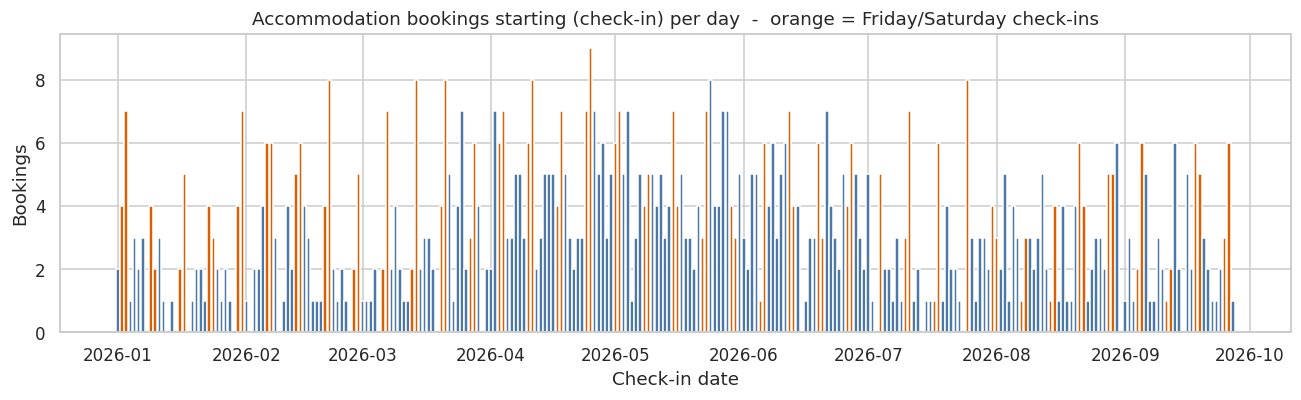


>> Finding: 882 calendar-placed accommodation bookings over 270 days (mean 3.27 check-ins/day on days with data). The busiest check-in day was 2026-04-25 (Sat) with 9 check-ins; 17 day(s) had none. 


In [ ]:
first_d, last_d = dt["Check-In Date"].min(), dt["Check-In Date"].max()          # VALID accommodation dates only
span_days = (last_d - first_d).days + 1
daily_bookings = daily_series(dt)                                                      # NaN (not 0) inside months with no data
_gaps5 = month_gaps(dt)

if span_days >= 14:
    fig, ax = plt.subplots(figsize=(12, 3.8))
    colors = ["#d95f02" if d.dayofweek in WEEKEND_NIGHTS else "#4c78a8" for d in daily_bookings.index]
    ax.bar(daily_bookings.index, daily_bookings.values, color=colors, width=0.85)
    for g_ in _gaps5:
        ax.axvspan(g_.start_time, g_.end_time, color="#bbbbbb", alpha=0.35)
        ax.text(g_.start_time + (g_.end_time - g_.start_time) / 2, ax.get_ylim()[1] * 0.5, f"NO DATA\n{g_}\n(not zero)", ha="center", fontsize=9, color="#444444")
    ax.set_title("Accommodation bookings starting (check-in) per day  -  orange = Friday/Saturday check-ins")
    ax.set_ylabel("Bookings"); ax.set_xlabel("Check-in date")
    plt.tight_layout(); plt.show()
else:
    print("Fewer than 14 calendar days - daily chart skipped.")

busiest = daily_bookings.idxmax()
finding(f"{len(dt)} calendar-placed accommodation bookings over {span_days} days (mean {daily_bookings.mean():.2f} check-ins/day on days with data). "
        f"The busiest check-in day was {busiest.date()} ({DOW_NAMES[busiest.dayofweek]}) with {int(daily_bookings.max())} check-ins; "
        f"{int((daily_bookings == 0).sum())} day(s) had none. "
        + (f"{int(daily_bookings.isna().sum())} day(s) fall in month(s) with NO data ({', '.join(map(str, _gaps5))}) and are NOT counted as zero." if _gaps5 else ""))

### 5.2 Which weekdays do guests check in?  (weekly pattern)

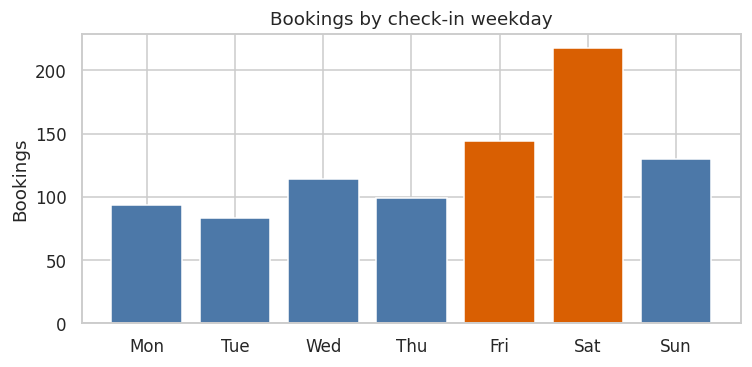


>> Finding: Sat had the most check-ins (218 of 882, 25%). Friday+Saturday together account for 41% of check-ins.


In [ ]:
if span_days >= 21:
    dow_counts = dt["Check-In DOW"].value_counts().reindex(range(7), fill_value=0)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(DOW_NAMES, dow_counts.values, color=["#d95f02" if i in WEEKEND_NIGHTS else "#4c78a8" for i in range(7)])
    ax.set_title("Bookings by check-in weekday"); ax.set_ylabel("Bookings")
    plt.tight_layout(); plt.show()
    top = dow_counts.idxmax()
    finding(f"{DOW_NAMES[top]} had the most check-ins ({dow_counts.max()} of {dow_counts.sum()}, {dow_counts.max()/dow_counts.sum():.0%}). "
            f"Friday+Saturday together account for {dow_counts[[4,5]].sum()/dow_counts.sum():.0%} of check-ins.")
else:
    print("Need at least 21 days of data for a weekly pattern - skipped.")

### 5.3 What do bookings look like?  (nights, guests, source, add-ons)

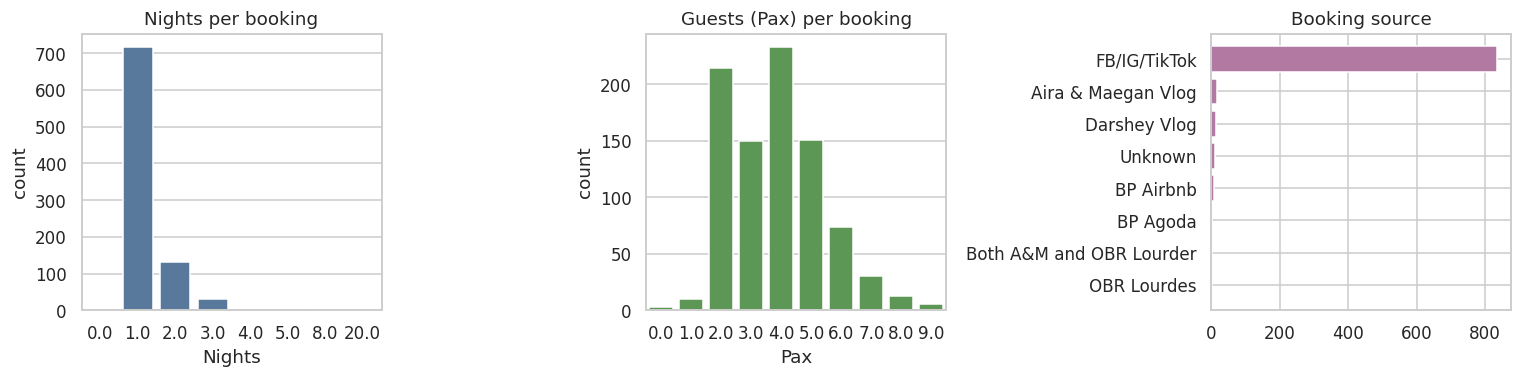


>> Finding: Median stay = 1 night(s); 81% of bookings are 1-night stays. Median party size = 4 guests. 'FB/IG/TikTok' is the recorded source for 94% of bookings (source is heavily concentrated, so it carries little information for modelling).
Bookings using each add-on: {'Extra Hours': 79, 'Pool Voucher': 23, 'Parking': 59, 'Setup Decor': 7, 'Massage': 5, 'Airport Shuttle': 2}
Add-ons never used in this data: none


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
sns.countplot(x="Nights", data=df_accom, ax=axes[0], color="#4c78a8"); axes[0].set_title("Nights per booking")
sns.countplot(x="Pax", data=df_accom, ax=axes[1], color="#54a24b"); axes[1].set_title("Guests (Pax) per booking")
src = df_accom["Source"].value_counts()
axes[2].barh(src.index[::-1], src.values[::-1], color="#b279a2"); axes[2].set_title("Booking source")
plt.tight_layout(); plt.show()

addon_use = pd.Series({c: int((df_accom[c] > 0).sum()) for c in ADDON_COLS})
finding(f"Median stay = {df_accom['Nights'].median():.0f} night(s); {(df_accom['Nights']==1).mean():.0%} of bookings are 1-night stays. "
        f"Median party size = {df_accom['Pax'].median():.0f} guests. "
        f"'{src.index[0]}' is the recorded source for {src.iloc[0]/src.sum():.0%} of bookings "
        f"(source is heavily concentrated, so it carries little information for modelling).")
print("Bookings using each add-on:", addon_use.to_dict())
print("Add-ons never used in this data:", [c for c, v in addon_use.items() if v == 0] or "none")

### 5.4 How are bills distributed?  (target/revenue distribution and outlier investigation)

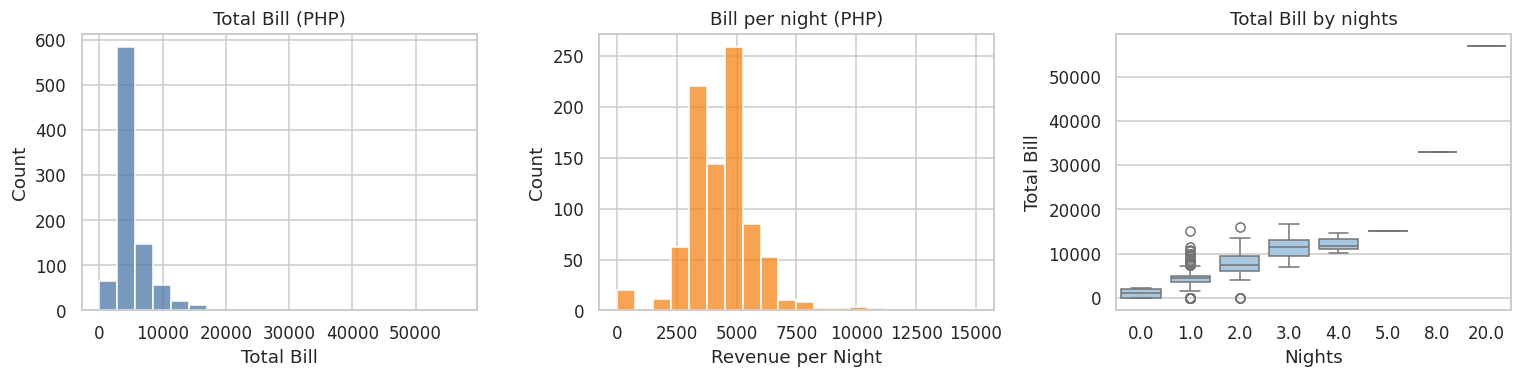

IQR outliers - Total Bill: 69, bill per night: 42


,Record ID,Unit ID,Nights,Pax,Extra Hours,Total Bill,Revenue per Night
2,D-SEPT26 (2) (1)|B0003,MATILDA,3.00,4.00,0,"10,200.00","3,400.00"
9,D-SEPT26 (2) (1)|B0010,JULIANA,3.00,5.00,0,"12,000.00","4,000.00"
10,D-SEPT26 (2) (1)|B0011,VICTORIA,3.00,5.00,0,"12,000.00","4,000.00"
17,D-SEPT26 (2) (1)|B0018,ELIZABETH,3.00,6.00,0,"11,100.00","3,700.00"
57,D-SEPT26 (2) (1)|B0058,VICTORIA,4.00,3.00,0,"11,775.00","2,943.75"
...,...,...,...,...,...,...,...
835,D-APR26 (1)|B0043,JULIANA,2.00,4.00,0,"10,000.00","5,000.00"
840,D-APR26 (1)|B0048,VICTORIA,3.00,4.00,0,"12,750.00","4,250.00"
877,D-APR26 (1)|B0085,JULIANA,3.00,2.00,0,"10,500.00","3,500.00"
910,D-APR26 (1)|B0118,VICTORIA,1.00,5.00,0,"10,500.00","10,500.00"



>> Finding: 69 bills are statistical outliers by the IQR rule. 62 of them are longer-than-median stays, and 42 bookings are outliers on price per night. A high bill that is explained by more nights is a legitimate extreme value, not a data error, so no outlier is removed. Bills with a high per-night price should be checked against the source records.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
sns.histplot(df_accom["Total Bill"].dropna(), bins=20, ax=axes[0], color="#4c78a8"); axes[0].set_title("Total Bill (PHP)")
sns.histplot(df_accom["Revenue per Night"].dropna(), bins=20, ax=axes[1], color="#f58518"); axes[1].set_title("Bill per night (PHP)")
sns.boxplot(x="Nights", y="Total Bill", data=df_accom, ax=axes[2], color="#9ecae9"); axes[2].set_title("Total Bill by nights")
plt.tight_layout(); plt.show()

def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return (s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)

o_bill, o_pn = iqr_outliers(df_accom["Total Bill"].dropna()), iqr_outliers(df_accom["Revenue per Night"].dropna())
flag_bill = df_accom.loc[o_bill[o_bill].index]
flag_pn = df_accom.loc[o_pn[o_pn].index]
print(f"IQR outliers - Total Bill: {len(flag_bill)}, bill per night: {len(flag_pn)}")
if len(flag_bill):
    display(flag_bill[["Record ID","Unit ID","Nights","Pax","Extra Hours","Total Bill","Revenue per Night"]])
finding(f"{len(flag_bill)} bills are statistical outliers by the IQR rule. "
        f"{int((flag_bill['Nights'] > df_accom['Nights'].median()).sum())} of them are longer-than-median stays, and {len(flag_pn)} bookings are outliers on price per night. "
        "A high bill that is explained by more nights is a legitimate extreme value, not a data error, so no outlier is removed. "
        "Bills with a high per-night price should be checked against the source records.")

### 5.5 What is related to the bill?  (feature-target relationships)

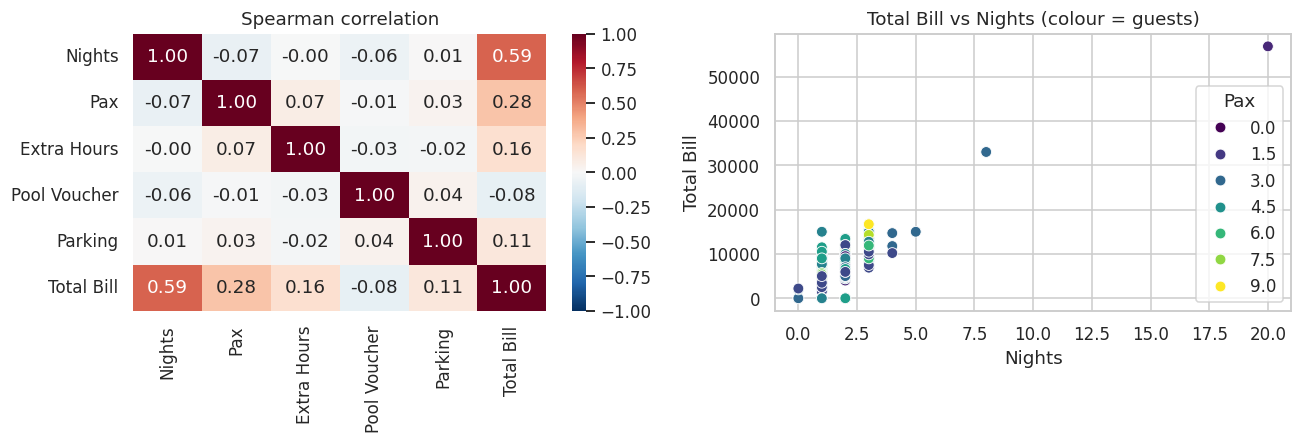


>> Finding: Total Bill is most strongly rank-correlated with Nights (rho = 0.59) and Pax (rho = 0.28). Correlation shows association only; it does not show that either variable causes the bill.


In [ ]:
rel_cols = ["Nights", "Pax", "Extra Hours", "Pool Voucher", "Parking", "Total Bill"]
corr = df_accom[rel_cols].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[0]); axes[0].set_title("Spearman correlation")
sns.scatterplot(data=df_accom, x="Nights", y="Total Bill", hue="Pax", palette="viridis", ax=axes[1], s=50)
axes[1].set_title("Total Bill vs Nights (colour = guests)")
plt.tight_layout(); plt.show()
finding(f"Total Bill is most strongly rank-correlated with Nights (rho = {corr.loc['Total Bill','Nights']:.2f}) and Pax "
        f"(rho = {corr.loc['Total Bill','Pax']:.2f}). Correlation shows association only; it does not show that either variable causes the bill.")

### 5.6 EDA summary and what it implies for modelling

* **Time coverage decides which models are legitimate** (Section 9). Descriptive analysis is valid for any amount of data; forecasting needs long history.
* Most bookings are short stays; the bill is mainly driven by stay length and guest count, so *booking count* (not bill) is the cleaner demand signal.
* Source and several add-on columns are nearly constant, so they carry little modelling information and are **not used as forecast features**.
* Legitimate high bills (long stays) are kept; only records that are logically impossible would be removed.
* Check-in dates are used as the demand date, and the calendar-based work excludes records with missing or out-of-window dates. All EDA uses the 10 accommodation units only (`df_accom` / `dt`).

# 6. Booking Trend Analysis

Three kinds of statements are kept separate throughout:

* **Observed pattern** – a number or chart taken directly from the data.
* **Possible interpretation** – a cautious explanation that the data alone cannot prove.
* **Statistical / model-based finding** – a result from a test or model, reported with its limits.

A few weeks of data cannot show a *trend*; they can only describe *that period*. The code below refuses to describe month-to-month movement unless enough months exist.

,Value
Accommodation records (10 units),890
Bookings placed on the calendar (valid dates),882
Total booked nights,1113
Average nights per booking,1.26
Average pax per booking,3.83
Mean check-ins per calendar day (days with data),3.27
Median check-ins per calendar day,3.00
Maximum check-ins on one day,9
Calendar days with no check-in (in months with data),17
Months with data,9


Weekend vs weekday check-ins:


,Bookings,Avg_nights,Avg_pax,Avg_bill,Avg_bill_per_night
Weekend Check-In,,,,,
Sun-Thu check-in,520,1.33,3.64,"5,267.39","4,061.25"
Fri/Sat check-in,362,1.16,4.10,"5,298.43","4,649.08"



>> Finding: Fri/Sat check-ins averaged PHP 4,649 per night versus PHP 4,061 for Sun-Thu check-ins (Mann-Whitney p = 2.84e-20). Fri/Sat stays were *associated with* different observed prices in this dataset; this does not show that the weekday causes the price, and price rules or unit mix may explain it.


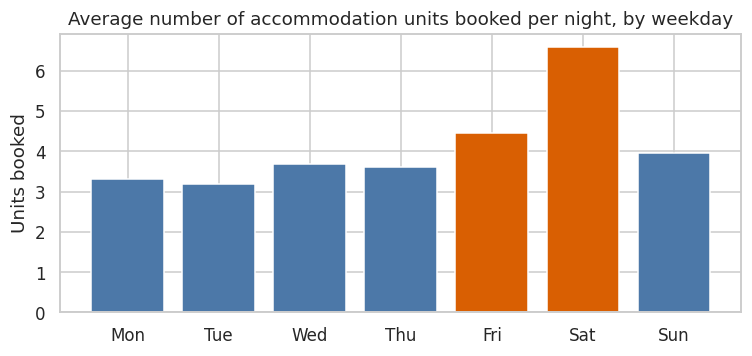


>> Finding: On average 6.6 units were booked on Sat nights versus 3.2 on Tue nights. This is a count of booked units, not an occupancy percentage (see Section 14 for the estimated occupancy).


In [ ]:
n_months = dt["Check-In Month"].nunique()
summary = {
    "Accommodation records (10 units)": len(df_accom),
    "Bookings placed on the calendar (valid dates)": len(dt),
    "Total booked nights": int(dt["Nights"].sum()),
    "Average nights per booking": dt["Nights"].mean(),
    "Average pax per booking": dt["Pax"].mean(),
    "Mean check-ins per calendar day (days with data)": daily_bookings.mean(),
    "Median check-ins per calendar day": daily_bookings.median(),
    "Maximum check-ins on one day": int(daily_bookings.max()),
    "Calendar days with no check-in (in months with data)": int((daily_bookings == 0).sum()),
    "Months with data": n_months,
    "Months in range with NO data (missing / invalid, not zero)": ", ".join(map(str, _gaps5)) or "none",
}
display(pd.Series(summary, name="Value").to_frame())

# ---- weekend vs weekday behaviour (calendar-based; assumption in section 2.1) ----
wk = dt.groupby("Weekend Check-In").agg(Bookings=("Record ID", "count"), Avg_nights=("Nights", "mean"),
        Avg_pax=("Pax", "mean"), Avg_bill=("Total Bill", "mean"), Avg_bill_per_night=("Revenue per Night", "mean"))
wk.index = wk.index.map({True: "Fri/Sat check-in", False: "Sun-Thu check-in"})
print("Weekend vs weekday check-ins:"); display(wk)
if len(wk) == 2 and wk["Bookings"].min() >= 8:
    a = dt.loc[dt["Weekend Check-In"], "Revenue per Night"].dropna()
    b = dt.loc[~dt["Weekend Check-In"], "Revenue per Night"].dropna()
    u, pval = stats.mannwhitneyu(a, b, alternative="two-sided")
    finding(f"Fri/Sat check-ins averaged PHP {a.mean():,.0f} per night versus PHP {b.mean():,.0f} for Sun-Thu check-ins "
            f"(Mann-Whitney p = {pval:.3g}). Fri/Sat stays were *associated with* different observed prices in this dataset; "
            "this does not show that the weekday causes the price, and price rules or unit mix may explain it.")
else:
    print("One weekday group has fewer than 8 bookings - no significance test run.")

# ---- average occupied units per night by weekday (accommodation units only; months with no data excluded) ----
nd = nights_tbl.groupby("Night Date").size()
nd = nd.reindex(pd.date_range(nd.index.min(), nd.index.max(), freq="D"), fill_value=0).astype(float)
nd[np.asarray(nd.index.to_period("M").isin(_gaps5))] = np.nan
avg_by_dow = nd.groupby(nd.index.dayofweek).mean().reindex(range(7))
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(DOW_NAMES, avg_by_dow.values, color=["#d95f02" if i in WEEKEND_NIGHTS else "#4c78a8" for i in range(7)])
ax.set_title("Average number of accommodation units booked per night, by weekday"); ax.set_ylabel("Units booked")
plt.tight_layout(); plt.show()
finding(f"On average {avg_by_dow.max():.1f} units were booked on {DOW_NAMES[int(avg_by_dow.idxmax())]} nights versus "
        f"{avg_by_dow.min():.1f} on {DOW_NAMES[int(avg_by_dow.idxmin())]} nights. "
        "This is a count of booked units, not an occupancy percentage (see Section 14 for the estimated occupancy).")

,Bookings,Booked_nights,Revenue,Avg_bill,Avg_pax,Bookings change vs prev. month (%),Coverage note
2026-01,70,101.00,"387,674.30","5,538.20",4.36,NaN,
2026-02,77,94.00,"391,050.00","5,078.57",4.40,10.00,
2026-03,90,102.00,"423,750.00","4,708.33",4.00,16.88,
2026-04,144,176.00,"776,050.00","5,389.24",3.85,60.00,
2026-05,144,184.00,"746,380.00","5,183.19",3.88,0.00,
2026-06,118,146.00,"626,954.00","5,404.78",3.84,-18.06,
2026-07,76,101.00,"423,589.25","5,647.86",3.23,-35.59,
2026-08,90,114.00,"458,643.68","5,096.04",3.24,18.42,
2026-09,73,95.00,"407,150.00","5,577.40",3.70,-18.89,last check-in on 2026-09-27 (month may be inco...


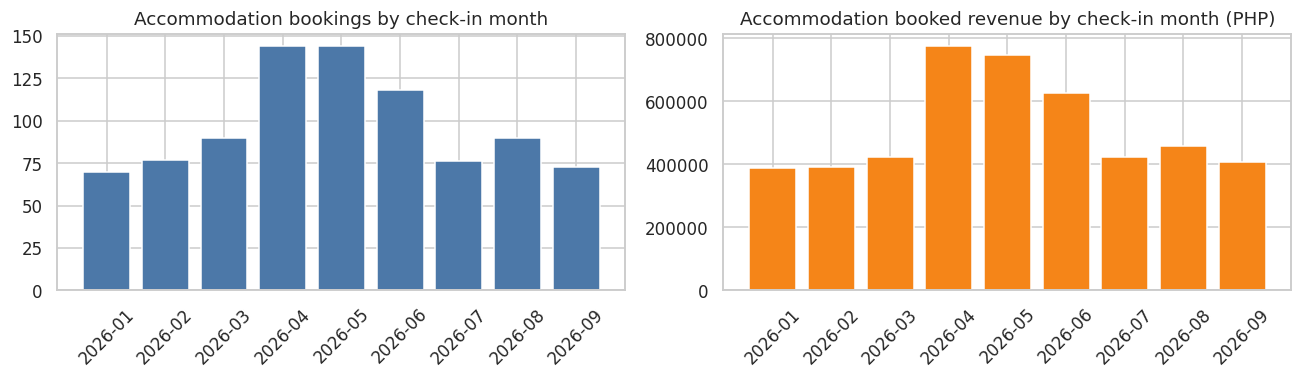


>> Finding: Kendall rank correlation between month order and bookings: tau = 0.00 (p = 1, n = 9 months with data). A positive tau would suggest an upward drift and a negative one a downward drift, but with this few observations it is weak evidence.

Note: seasonality (e.g. 'December is busier') cannot be claimed with 9 month(s); at least 24 months (two full cycles) are needed.


In [ ]:
# ---- monthly view (only meaningful with several months). Months with no data are shown as NO DATA, never as zero ----
_mi = pd.period_range(dt["Check-In Month"].min(), dt["Check-In Month"].max(), freq="M")
months = dt.groupby("Check-In Month").agg(Bookings=("Record ID", "count"), Booked_nights=("Nights", "sum"),
            Revenue=("Total Bill", "sum"), Avg_bill=("Total Bill", "mean"), Avg_pax=("Pax", "mean")).reindex(_mi)
months["Bookings change vs prev. month (%)"] = (months["Bookings"] / months["Bookings"].shift(1) - 1) * 100

# flag months whose first/last observed day suggests incomplete coverage
flags = {}
fm, lm = dt["Check-In Month"].min(), dt["Check-In Month"].max()
if first_d.day > 1: flags[fm] = "starts after day 1"
if last_d != last_d + pd.offsets.MonthEnd(0): flags[lm] = f"last check-in on {last_d.date()} (month may be incomplete)"
for g_ in _gaps5: flags[g_] = "NO DATA - month missing or invalid (NOT zero demand)"
months["Coverage note"] = [flags.get(m, "") for m in months.index]
display(months)

if n_months >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    x = [str(m) + ("\n(no data)" if m in _gaps5 else "") for m in months.index]
    axes[0].bar(x, months["Bookings"], color="#4c78a8"); axes[0].set_title("Accommodation bookings by check-in month"); axes[0].tick_params(axis="x", rotation=45)
    axes[1].bar(x, months["Revenue"], color="#f58518"); axes[1].set_title("Accommodation booked revenue by check-in month (PHP)"); axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout(); plt.show()

if n_months < 2:
    finding("Only one month is available, so month-to-month movement cannot be assessed. Everything in this section describes that single month, not a trend.")
elif n_months < MIN_MONTHS_TREND_STAT:
    finding(f"{n_months} months are available. Month-to-month changes are shown descriptively, but fewer than {MIN_MONTHS_TREND_STAT} months is too few to call a change a trend.")
else:
    _b = months["Bookings"].dropna()
    tau, p = stats.kendalltau(np.arange(len(_b)), _b.values)
    finding(f"Kendall rank correlation between month order and bookings: tau = {tau:.2f} (p = {p:.3g}, n = {len(_b)} months with data"
            + (f"; {len(_gaps5)} month(s) with no data were skipped, not set to zero" if _gaps5 else "") + "). "
            "A positive tau would suggest an upward drift and a negative one a downward drift, but with this few observations it is weak evidence.")
if n_months < MIN_MONTHS_SEASONAL:
    print(f"\nNote: seasonality (e.g. 'December is busier') cannot be claimed with {n_months} month(s); at least {MIN_MONTHS_SEASONAL} months (two full cycles) are needed.")

# 7. Unit Demand Analysis

Metrics per accommodation unit, using objective counts and sums. The comparisons are **factual**, not rankings of "good" or "bad" units: units may differ in size, price, features, and availability, and availability is not recorded, so a unit with fewer bookings is not necessarily less popular.

**Only the 10 accommodation units are shown** (parking, decor, airport pick-up and other add-ons are not units). A unit with no valid booking is listed with 0. Units with fewer than 20 bookings are described but never modelled.

,Location,Category,Bookings,Total_nights,Avg_stay,Avg_pax,Total_revenue,Avg_revenue_per_booking,Share of bookings,Share of nights,Share of revenue,Revenue per night,Modelled in unit forecast?
Unit ID,,,,,,,,,,,,,
MATILDA,Shore Residence (Pasay),Direct To Pool,127,146.00,1.15,3.68,"655,772.00","5,204.54",14.4%,13.1%,14.1%,"4,491.59",eligible
MARGARET,Shore Residence (Pasay),Direct To Pool,121,136.00,1.12,3.99,"630,810.00","5,256.75",13.7%,12.2%,13.6%,"4,638.31",eligible
ELIZABETH,Shore Residence (Pasay),Direct To Pool,115,146.00,1.27,3.73,"680,572.00","5,918.02",13.0%,13.1%,14.7%,"4,661.45",eligible
JULIANA,Shore Residence (Pasay),Direct To Pool,113,135.00,1.19,3.85,"637,044.25","5,687.90",12.8%,12.1%,13.7%,"4,718.85",eligible
GABRIEL,Shore Residence (Pasay),Family Suites,110,140.00,1.27,3.61,"446,451.68","4,058.65",12.5%,12.6%,9.6%,"3,188.94",eligible
VICTORIA,Shore Residence (Pasay),Direct To Pool,109,163.00,1.50,3.50,"715,416.30","6,563.45",12.4%,14.6%,15.4%,"4,389.06",eligible
ELEANOR,Shore Residence (Pasay),Family Suites,92,123.00,1.34,3.46,"367,800.00","3,997.83",10.4%,11.1%,7.9%,"2,990.24",eligible
DIANA,Shore Residence (Pasay),Family Suites,91,120.00,1.32,5.05,"497,575.00","5,467.86",10.3%,10.8%,10.7%,"4,146.46",eligible
LEA,Fame Residence (Mandaluyong),Not specified,3,3.00,1.00,2.33,"7,800.00","2,600.00",0.3%,0.3%,0.2%,"2,600.00",no (< 20 bookings)


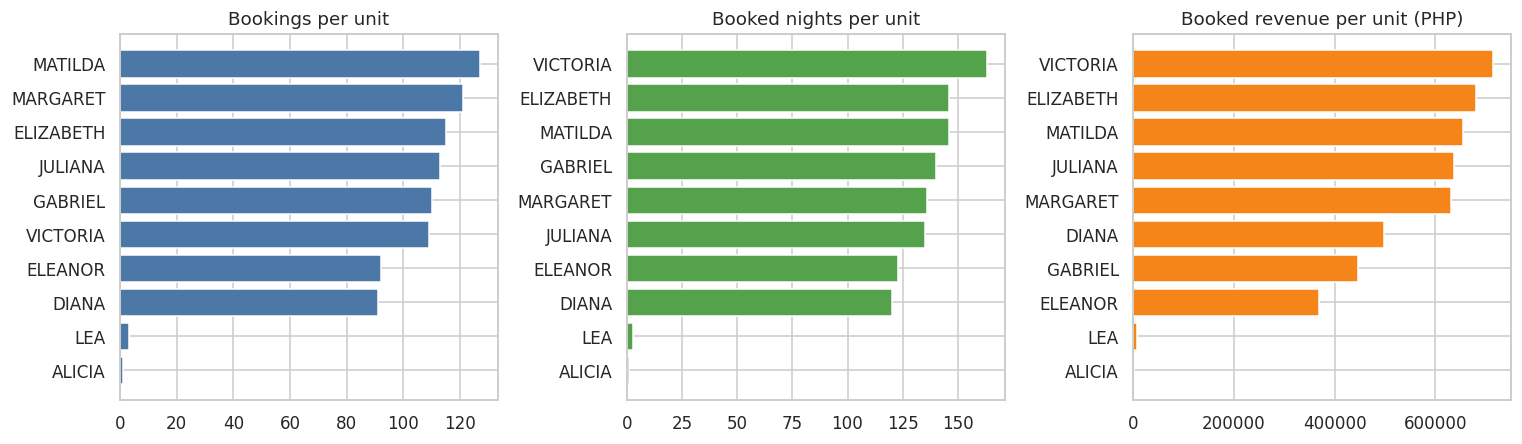


>> Finding: Among the 10 accommodation units, MATILDA received the most bookings (127) and ALICIA the fewest with any booking (1). By booked nights, VICTORIA had 163 and ALICIA had 1. By booked revenue, VICTORIA totalled PHP 715,416 versus PHP 2,000 for ALICIA. Units under 20 bookings are described here but never modelled. These counts are unadjusted for how many days each unit was available.


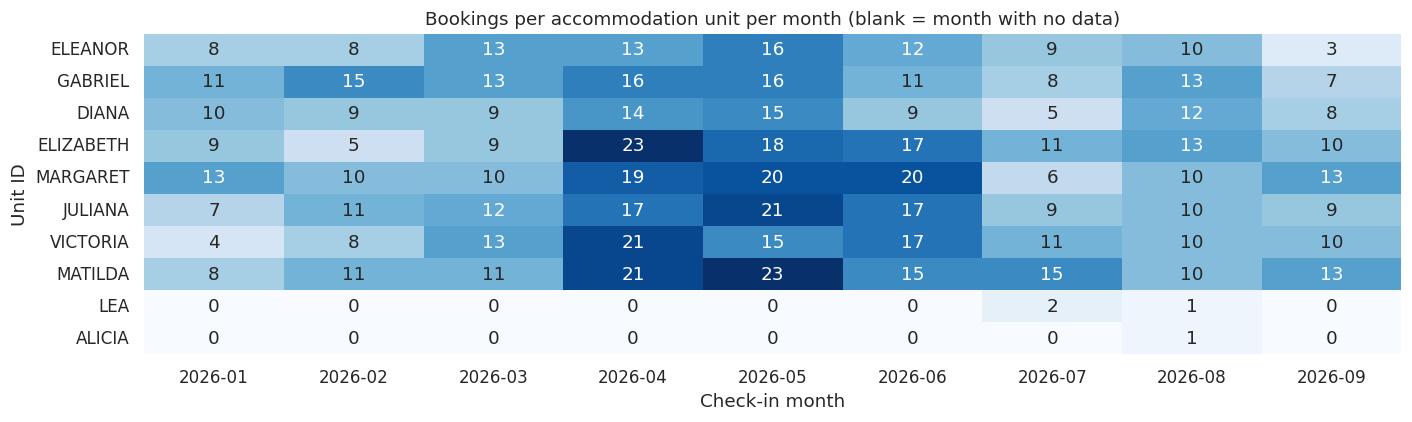

In [ ]:
# ---- unit demand: the 10 accommodation units ONLY (parking / add-ons are not units) ----
unit = dt.groupby("Unit ID").agg(Bookings=("Record ID", "count"), Total_nights=("Nights", "sum"), Avg_stay=("Nights", "mean"),
        Avg_pax=("Pax", "mean"), Total_revenue=("Total Bill", "sum"), Avg_revenue_per_booking=("Total Bill", "mean"))
unit = unit.reindex(ACCOMMODATION_UNITS)                                  # all 10 units always listed; 0 = no valid booking in the loaded data
for c in ["Bookings", "Total_nights", "Total_revenue"]:
    unit[c] = unit[c].fillna(0)
unit["Share of bookings"] = unit["Bookings"] / unit["Bookings"].sum()
unit["Share of nights"]   = unit["Total_nights"] / unit["Total_nights"].sum()
unit["Share of revenue"]  = unit["Total_revenue"] / unit["Total_revenue"].sum()
unit["Revenue per night"] = unit["Total_revenue"] / unit["Total_nights"].where(unit["Total_nights"] > 0)
unit = unit.sort_values("Bookings", ascending=False)
fmt = unit.copy()
for c in ["Share of bookings", "Share of nights", "Share of revenue"]:
    fmt[c] = (fmt[c] * 100).round(1).astype(str) + "%"
fmt.insert(0, "Category", [UNIT_CATEGORY[u] for u in fmt.index]); fmt.insert(0, "Location", [UNIT_LOCATION[u] for u in fmt.index])
fmt["Modelled in unit forecast?"] = np.where(unit["Bookings"] >= MIN_UNIT_BOOKINGS, "eligible", f"no (< {MIN_UNIT_BOOKINGS} bookings)")
display(fmt)
assert set(unit.index) == set(ACCOMMODATION_UNITS)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, t, colr in zip(axes, ["Bookings", "Total_nights", "Total_revenue"],
                            ["Bookings per unit", "Booked nights per unit", "Booked revenue per unit (PHP)"],
                            ["#4c78a8", "#54a24b", "#f58518"]):
    d = unit[col].sort_values()
    ax.barh(d.index, d.values, color=colr); ax.set_title(t)
plt.tight_layout(); plt.show()

_has = unit[unit["Bookings"] > 0]
hi, lo = _has["Bookings"].idxmax(), _has["Bookings"].idxmin()
hn, ln = _has["Total_nights"].idxmax(), _has["Total_nights"].idxmin()
hr, lr = _has["Total_revenue"].idxmax(), _has["Total_revenue"].idxmin()
_zero = [u for u in unit.index if unit.loc[u, "Bookings"] == 0]
finding(f"Among the 10 accommodation units, {hi} received the most bookings ({int(unit.loc[hi,'Bookings'])}) and {lo} the fewest with any booking ({int(unit.loc[lo,'Bookings'])}). "
        f"By booked nights, {hn} had {int(unit.loc[hn,'Total_nights'])} and {ln} had {int(unit.loc[ln,'Total_nights'])}. "
        f"By booked revenue, {hr} totalled PHP {unit.loc[hr,'Total_revenue']:,.0f} versus PHP {unit.loc[lr,'Total_revenue']:,.0f} for {lr}. "
        + (f"No valid booking was found for: {', '.join(_zero)}. " if _zero else "")
        + f"Units under {MIN_UNIT_BOOKINGS} bookings are described here but never modelled. These counts are unadjusted for how many days each unit was available.")

if n_months >= 2:
    _mi2 = pd.period_range(dt["Check-In Month"].min(), dt["Check-In Month"].max(), freq="M")
    piv = (dt.pivot_table(index="Unit ID", columns="Check-In Month", values="Record ID", aggfunc="count", fill_value=0)
             .reindex(index=ACCOMMODATION_UNITS, fill_value=0).reindex(columns=_mi2))      # months with no data stay NaN (blank), not 0
    plt.figure(figsize=(1.0 * len(_mi2) + 4, 4.0))
    sns.heatmap(piv, annot=True, fmt=".0f", cmap="Blues", cbar=False, mask=piv.isna())
    plt.title("Bookings per accommodation unit per month (blank = month with no data)"); plt.xlabel("Check-in month"); plt.tight_layout(); plt.show()

# 8. Revenue Analysis

**Definition used:** *booked revenue* = `Total Bill` of each booking, attributed to the booking's **check-in** date. It is the value of bookings, **not cash received** (many bookings are still "With Balance"). Downpayment and remaining balance are summarised separately.

Revenue is reported in **three clearly labelled scopes**: total across all records, accommodation-only (the 10 units), and add-on / parking / service rows. Revenue-over-time charts use accommodation bookings with valid dates only.

,Revenue scope,Records,Booked revenue (PHP)
0,TOTAL booked revenue - ALL records (accommodat...,953,"4,762,790.23"
1,ACCOMMODATION-ONLY booked revenue (the 10 units),890,"4,669,740.23"
2,ADD-ON / PARKING / SERVICE rows booked revenue...,43,"33,950.00"
3,Other out-of-scope or missing-Unit-ID rows boo...,20,"59,100.00"


Note: these totals use every record of the scope, including rows whose check-in date is invalid (revenue does not need a date). Bills of accommodation rows may already include add-ons billed on the same row; the data cannot separate those.



,Value
Accommodation-only booked revenue (PHP),"4,669,740.23"
Downpayments recorded - accommodation (PHP),"2,479,795.47"
Remaining balances recorded - accommodation (PHP),"1,961,207.33"
Average revenue per accommodation booking (PHP),"5,264.65"
Median revenue per accommodation booking (PHP),"5,000.00"
Revenue per booked accommodation night (PHP),"4,169.38"
Share of accommodation bookings fully paid,0.44


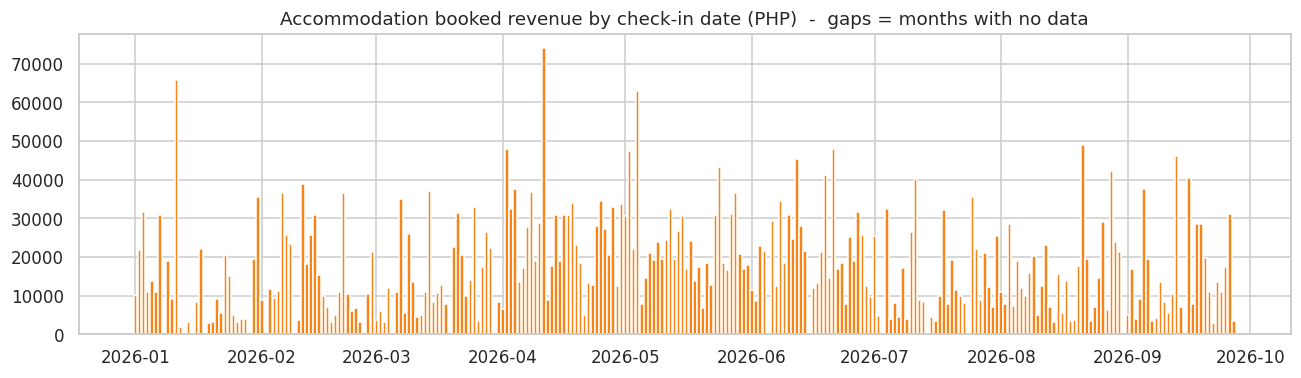

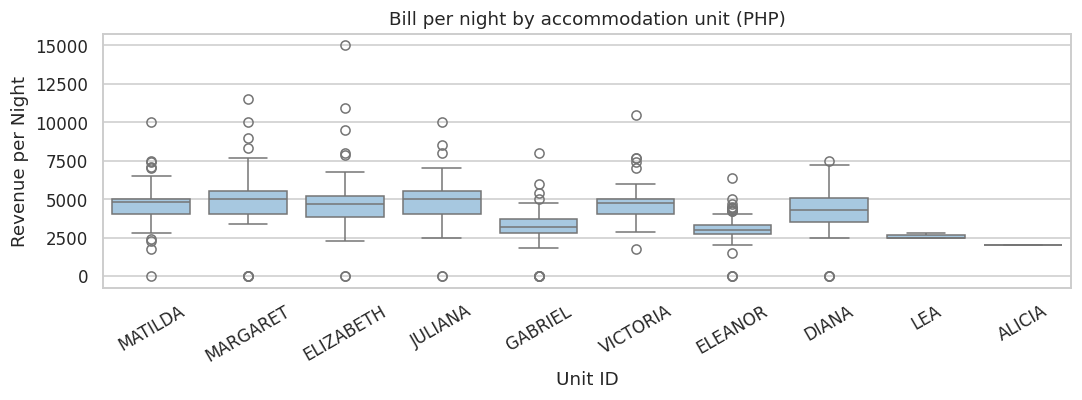


>> Finding: Accommodation booked revenue totals PHP 4,669,740 across 890 bookings (mean PHP 5,265 per booking, PHP 4,169 per booked night); add-on / parking rows add PHP 33,950 separately. VICTORIA contributed the largest share of accommodation revenue (15%) and ALICIA the smallest (0%). Differences in price per night between units may reflect unit type, capacity, or add-ons; the data cannot separate these.


In [ ]:
# ---- three clearly separated revenue scopes (booked value = Total Bill; not cash received) ----
_addon = df_non_accom[df_non_accom["Unit Class"] == "add-on/service"]
_other = df_non_accom[df_non_accom["Unit Class"] != "add-on/service"]
rev_tbl = pd.DataFrame([
    ["TOTAL booked revenue - ALL records (accommodation + add-on/parking + other)", len(df_all), df_all["Total Bill"].sum()],
    ["ACCOMMODATION-ONLY booked revenue (the 10 units)", len(df_accom), df_accom["Total Bill"].sum()],
    ["ADD-ON / PARKING / SERVICE rows booked revenue (reported separately)", len(_addon), _addon["Total Bill"].sum()],
    ["Other out-of-scope or missing-Unit-ID rows booked revenue", len(_other), _other["Total Bill"].sum()],
], columns=["Revenue scope", "Records", "Booked revenue (PHP)"])
display(rev_tbl)
assert abs(rev_tbl.iloc[0, 2] - rev_tbl.iloc[1:, 2].sum()) < 0.01, "revenue scopes do not reconcile"
print("Note: these totals use every record of the scope, including rows whose check-in date is invalid (revenue does not need a date). "
      "Bills of accommodation rows may already include add-ons billed on the same row; the data cannot separate those.\n")

_acc_n = df_accom[df_accom["Nights"] >= 1]
rev = {
    "Accommodation-only booked revenue (PHP)": df_accom["Total Bill"].sum(),
    "Downpayments recorded - accommodation (PHP)": df_accom["Downpayment"].sum(),
    "Remaining balances recorded - accommodation (PHP)": df_accom["Remaining Balance"].sum(),
    "Average revenue per accommodation booking (PHP)": df_accom["Total Bill"].mean(),
    "Median revenue per accommodation booking (PHP)": df_accom["Total Bill"].median(),
    "Revenue per booked accommodation night (PHP)": _acc_n["Total Bill"].sum() / _acc_n["Nights"].sum(),
    "Share of accommodation bookings fully paid": (df_accom["Status"].str.lower() == "fully paid").mean(),
}
display(pd.Series(rev, name="Value").to_frame())

# revenue over time (accommodation, valid dates). Months with no data are blank, not zero.
daily_revenue = daily_series(dt, "Total Bill")
if span_days >= 14:
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.bar(daily_revenue.index, daily_revenue.values, color="#f58518", width=0.85)
    ax.set_title("Accommodation booked revenue by check-in date (PHP)  -  gaps = months with no data"); plt.tight_layout(); plt.show()

# price level by unit
fig, ax = plt.subplots(figsize=(10, 3.8))
_order = [u for u in unit.index if (dt["Unit ID"] == u).any()]
sns.boxplot(data=dt, x="Unit ID", y="Revenue per Night", order=_order, color="#9ecae9", ax=ax)
ax.set_title("Bill per night by accommodation unit (PHP)"); ax.tick_params(axis="x", rotation=30); plt.tight_layout(); plt.show()

top_units = unit.loc[unit["Total_revenue"] > 0, "Share of revenue"].sort_values(ascending=False)
finding(f"Accommodation booked revenue totals PHP {rev['Accommodation-only booked revenue (PHP)']:,.0f} across {len(df_accom)} bookings "
        f"(mean PHP {rev['Average revenue per accommodation booking (PHP)']:,.0f} per booking, PHP {rev['Revenue per booked accommodation night (PHP)']:,.0f} per booked night); "
        f"add-on / parking rows add PHP {_addon['Total Bill'].sum():,.0f} separately. "
        f"{top_units.index[0]} contributed the largest share of accommodation revenue ({top_units.iloc[0]:.0%}) and {top_units.index[-1]} the smallest ({top_units.iloc[-1]:.0%}). "
        "Differences in price per night between units may reflect unit type, capacity, or add-ons; the data cannot separate these.")

# 9. Forecasting Feasibility Assessment

Before any model is trained the notebook measures the history it actually has and compares it with the thresholds in Section 2.1.

**Why gates are needed.** A forecasting model learns patterns from past periods and is judged on later periods it has not seen. With one month there is no "later period" to learn or test on. With less than about a year, month-of-year effects cannot be separated from a one-off event.

**Single truth.** Everything here is computed from the cleaned accommodation data with valid dates (`dt`). The result is four flags - `CAN_FORECAST`, `CAN_UNIT_FORECAST`, `CAN_OCC`, `CAN_OCC_FORECAST` - printed at the end of the section and checked by Sections 10-14, so they cannot contradict this section.

In [ ]:
# ===== Section 9: feasibility is computed ONLY from the cleaned accommodation data (df_accom -> dt, valid dates) =====
first_d, last_d = dt["Check-In Date"].min(), dt["Check-In Date"].max()
assert first_d >= VALID_START and last_d <= VALID_END, "dt contains out-of-range dates"
span_days = (last_d - first_d).days + 1
first_m, last_m = dt["Check-In Month"].min(), dt["Check-In Month"].max()
month_span = pd.period_range(first_m, last_m, freq="M")
n_month_span = len(month_span)
n_months = dt["Check-In Month"].nunique()
bookings_by_month = dt.groupby("Check-In Month").size().reindex(month_span, fill_value=0)
gap_months = [str(m) for m in bookings_by_month[bookings_by_month == 0].index]      # months with ZERO valid bookings = missing/invalid, not "no demand"
GAP_PERIODS = set(pd.Period(m, freq="M") for m in gap_months)
_body = bookings_by_month.iloc[:-1]; _ref = _body[_body > 0]
thin_months = ([str(m) for m, v in _body.items() if 0 < v < THIN_MONTH_RATIO * _ref.median()] if len(_ref) >= 3 else [])

# ---- forecast window: whole calendar month(s) after the last month in the data ----
cur_month_end = last_d + pd.offsets.MonthEnd(0)
fc_target_end = cur_month_end + pd.offsets.MonthEnd(FORECAST_MONTHS_AHEAD)
HORIZON_DAYS  = int((fc_target_end - last_d).days)
print(f"Forecast window: {(last_d + pd.Timedelta(days=1)).date()} to {fc_target_end.date()} ({HORIZON_DAYS} days = whole calendar month(s)).")

# ---- inventory used for occupancy: the 10 accommodation units only; real (preferred) or clearly-labelled assumption ----
if INVENTORY is not None:
    _unknown = sorted(set(INVENTORY) - set(ACCOMMODATION_UNITS))
    if _unknown: print("INVENTORY entries that are not accommodation units were ignored:", _unknown)
    INV, INV_SOURCE = {u: v for u, v in INVENTORY.items() if u in ACCOMMODATION_UNITS}, "provided by the business"
elif ASSUME_UNITS_AVAILABLE:
    first_seen = dt.groupby("Unit ID")["Check-In Date"].min().dt.to_period("M").dt.start_time
    default_start = first_m.start_time
    INV = {u: (str(pd.Timestamp(first_seen.get(u, default_start)).date()), None) for u in ACCOMMODATION_UNITS}
    INV_SOURCE = "ESTIMATED / ASSUMED (each of the 10 units sellable every day from the month of its first booking; units without bookings from the first data month)"
else:
    INV, INV_SOURCE = None, "NOT available"

# ---- daily series (months with no data are NaN, never 0) and exact count of usable modelling rows ----
daily_bookings = daily_series(dt)
_h = HORIZON_DAYS
_ok = daily_bookings.notna() & daily_bookings.shift(_h).rolling(28).count().eq(28) & daily_bookings.shift(_h + 7).notna()
usable_rows_est = int(_ok.sum())
_fut = pd.date_range(last_d + pd.Timedelta(days=1), fc_target_end, freq="D")
_ext = daily_bookings.reindex(daily_bookings.index.union(_fut))
_fut_ok = (_ext.shift(_h).rolling(28).count().eq(28) & _ext.shift(_h + 7).notna()).reindex(_fut)
n_future_blocked = int((~_fut_ok).sum())            # forecast days whose lag window overlaps a missing month

first_full_mon = first_d + pd.Timedelta(days=(7 - first_d.dayofweek) % 7)
last_full_sun = last_d - pd.Timedelta(days=(last_d.dayofweek + 1) % 7)
weeks_all = pd.date_range(first_full_mon, last_full_sun - pd.Timedelta(days=6), freq="7D")
weeks_with_gap = [w for w in weeks_all if daily_bookings.reindex(pd.date_range(w, periods=7)).isna().any()]
n_full_weeks = len(weeks_all) - len(weeks_with_gap)
unit_bookings = dt.groupby("Unit ID").size().reindex(ACCOMMODATION_UNITS, fill_value=0)
eligible_units = sorted(unit_bookings[unit_bookings >= MIN_UNIT_BOOKINGS].index)

SEASONAL_OK = (n_month_span >= MIN_MONTHS_SEASONAL) if USE_MONTH_WEEK_FEATURES is None else bool(USE_MONTH_WEEK_FEATURES)
if USE_MONTH_WEEK_FEATURES and n_month_span < MIN_MONTHS_SEASONAL:
    print(f"WARNING: month / week-of-year features were forced ON with only {n_month_span} month(s); trees cannot extrapolate to an unseen month, so expect unreliable results.")

# ---- the single feasibility decision ----
def _mlabel(m): return pd.Period(m, freq="M").strftime("%B %Y")
def _stem(f): return re.sub(r"\s*\(\d+\)", "", os.path.splitext(f)[0]).strip()
problem_months = sorted(set(gap_months) | set(thin_months))
base_ok = (span_days >= MIN_DAYS_DAILY_ML) and (usable_rows_est >= MIN_USABLE_ROWS)
data_problem = bool(problem_months or unrecovered_files)

reasons = []
if data_problem and not ALLOW_MISSING_MONTHS:
    if problem_months:
        upl = [_stem(f) for f in unrecovered_files] or [f"D-{pd.Period(m, freq='M').strftime('%b').upper()}{pd.Period(m, freq='M').strftime('%y')}" for m in problem_months]
        reasons.append(f"Forecasting is deferred because {', '.join(_mlabel(m) for m in problem_months)} {'is' if len(problem_months) == 1 else 'are'} missing or invalid. "
                       f"Upload the correct {', '.join(upl)} workbook{'s' if len(upl) > 1 else ''} and re-run.")
    else:
        reasons.append(f"Forecasting is deferred because {', '.join(_stem(f) for f in unrecovered_files)} has invalid check-in dates that could not be recovered. Upload the corrected workbook and re-run.")
if data_problem and ALLOW_MISSING_MONTHS and n_future_blocked > 0:
    reasons.append(f"Forecasting is deferred because the lag window of {n_future_blocked} forecast day(s) overlaps the missing / invalid month(s) "
                   f"({', '.join(_mlabel(m) for m in problem_months) or 'unrecovered workbook'}), so their features cannot be built without inventing values - not even with ALLOW_MISSING_MONTHS = True. "
                   "Upload the correct workbook and re-run.")
if not base_ok:
    why = []
    if span_days < MIN_DAYS_DAILY_ML: why.append(f"the valid history spans only {span_days} days (< {MIN_DAYS_DAILY_ML})")
    if usable_rows_est < MIN_USABLE_ROWS: why.append(f"only {usable_rows_est} usable rows remain after lag warm-up (< {MIN_USABLE_ROWS})")
    reasons.append("Forecasting is deferred because the valid history is too short: " + "; ".join(why) + ".")
FORECAST_DEFERRED_MESSAGE = " ".join(reasons)
FORECAST_DEFERRED_REASON = FORECAST_DEFERRED_MESSAGE

CAN_FORECAST = not reasons
EXPERIMENTAL_FORECAST = bool(CAN_FORECAST and data_problem)       # only reachable when the user set ALLOW_MISSING_MONTHS = True
CAN_UNIT_FORECAST = CAN_FORECAST and (n_full_weeks >= MIN_UNIT_WEEKS) and (len(eligible_units) >= 2)
CAN_OCC = INV is not None
CAN_OCC_FORECAST = CAN_OCC and CAN_FORECAST

profile = {
    "Records (validated, all)": len(df_all), "Accommodation records (10 units)": len(df_accom),
    "Records placed on calendar (dt)": len(dt), "Non-accommodation rows (excluded)": len(df_non_accom),
    "Unique check-in dates": dt["Check-In Date"].nunique(),
    "Valid date range": f"{first_d.date()} to {last_d.date()} ({span_days} days)",
    "Forecast window": f"{(last_d + pd.Timedelta(days=1)).date()} to {fc_target_end.date()} ({HORIZON_DAYS} days)",
    "Distinct months with data": n_months, "Calendar months spanned": n_month_span,
    "Months in range with zero bookings (missing / invalid)": ", ".join(gap_months) or "none",
    "Months far below the others (probably incomplete)": ", ".join(thin_months) or "none",
    "Workbooks with unrecoverable dates": ", ".join(unrecovered_files) or "none",
    "Accommodation units with bookings": f"{int((unit_bookings > 0).sum())} of {len(ACCOMMODATION_UNITS)}",
    "Bookings per month (min / median / max)": f"{bookings_by_month.min()} / {bookings_by_month.median():.0f} / {bookings_by_month.max()}",
    "Mean bookings per day (days with data)": round(daily_bookings.mean(), 2),
    "Usable modelling rows after lag warm-up": usable_rows_est,
    "Nights per booking (mean, max)": f"{dt['Nights'].mean():.2f}, {int(dt['Nights'].max())}",
    "Revenue information available": bool(dt["Total Bill"].notna().any()),
    "Inventory / availability information": INV_SOURCE,
}
display(pd.Series(profile, name="Value").to_frame())

gate = pd.DataFrame([
    ["Descriptive analysis (Sections 5-8)", ">= 1 dated accommodation booking", f"{len(dt)} bookings", True],
    ["Month-to-month comparison", ">= 2 months", f"{n_months} month(s)", n_months >= 2],
    ["Trend statistic", f">= {MIN_MONTHS_TREND_STAT} months", f"{n_months} month(s)", n_months >= MIN_MONTHS_TREND_STAT],
    ["Seasonality claims / month features", f">= {MIN_MONTHS_SEASONAL} months", f"{n_month_span} month(s)", SEASONAL_OK],
    ["Overall demand forecast (3 ML models)", f">= {MIN_DAYS_DAILY_ML} days, >= {MIN_USABLE_ROWS} usable rows, no missing / invalid month",
        f"{span_days} days, {usable_rows_est} usable rows, missing: {len(gap_months)}, thin: {len(thin_months)}, bad files: {len(unrecovered_files)}", CAN_FORECAST],
    ["Unit-level forecast (10 units only)", f">= {MIN_UNIT_WEEKS} full weeks and >= 2 units with >= {MIN_UNIT_BOOKINGS} bookings",
        f"{n_full_weeks} full weeks, {len(eligible_units)} eligible unit(s)", CAN_UNIT_FORECAST],
    ["Occupancy analysis (10 units, estimated unless inventory is given)", "unit inventory / availability periods (or the stated assumption)", INV_SOURCE.split(" (")[0], CAN_OCC],
    ["Occupancy forecast", "occupancy analysis AND overall forecast feasible", "same", CAN_OCC_FORECAST],
], columns=["Analysis", "Requirement", "Current data", "Feasible?"])
gate["Feasible?"] = gate["Feasible?"].map({True: "YES", False: "NO - deferred"})
display(gate)

nights_started = dt.groupby("Check-In Date")["Nights"].sum().reindex(daily_bookings.index, fill_value=0).astype(float).where(daily_bookings.notna())
_m = daily_bookings.notna()
print(f"Spearman correlation between daily booking count and daily nights started (days with data): {stats.spearmanr(daily_bookings[_m], nights_started[_m])[0]:.2f}")

# ---- THE single truth used by Sections 10-14 ----
print("\n" + "=" * 70)
print("FEASIBILITY FLAGS (single source of truth for Sections 10-14)")
print(f"  CAN_FORECAST      = {CAN_FORECAST}")
print(f"  CAN_UNIT_FORECAST = {CAN_UNIT_FORECAST}")
print(f"  CAN_OCC           = {CAN_OCC}")
print(f"  CAN_OCC_FORECAST  = {CAN_OCC_FORECAST}")
print(f"  EXPERIMENTAL_FORECAST = {EXPERIMENTAL_FORECAST}  (ALLOW_MISSING_MONTHS = {ALLOW_MISSING_MONTHS})")
print("=" * 70)
assert not (CAN_UNIT_FORECAST and not CAN_FORECAST) and not (CAN_OCC_FORECAST and not CAN_FORECAST), "inconsistent feasibility flags"
assert not (EXPERIMENTAL_FORECAST and not ALLOW_MISSING_MONTHS)

if CAN_FORECAST and not EXPERIMENTAL_FORECAST:
    print("\nVERDICT: the valid accommodation data is long and complete enough for a chronological, leakage-safe forecasting experiment (Sections 10-14).")
elif CAN_FORECAST:
    bar = "!" * 100
    print("\n" + bar)
    print("EXPERIMENTAL FORECAST - UNRELIABLE.  ALLOW_MISSING_MONTHS = True and the data has missing / invalid month(s):", ", ".join(problem_months) or "unrecovered workbook(s)")
    print("Those days are left as UNKNOWN (NaN) and dropped from model training; they are NOT filled with zeros. Rows whose lag window touches them are dropped too.")
    print("Treat every number produced by Sections 10-14 as a demonstration only, not a planning figure.")
    print(bar)
else:
    print("\nVERDICT: " + FORECAST_DEFERRED_MESSAGE)
    print("Sections 5-8 (descriptive analysis) remain valid. Sections 10-13 and the occupancy FORECAST are skipped rather than forced.")

Forecast window: 2026-09-28 to 2026-10-31 (34 days = whole calendar month(s)).


,Value
"Records (validated, all)",953
Accommodation records (10 units),890
Records placed on calendar (dt),882
Non-accommodation rows (excluded),63
Unique check-in dates,253
Valid date range,2026-01-01 to 2026-09-27 (270 days)
Forecast window,2026-09-28 to 2026-10-31 (34 days)
Distinct months with data,9
Calendar months spanned,9
Months in range with zero bookings (missing / invalid),none


,Analysis,Requirement,Current data,Feasible?
0,Descriptive analysis (Sections 5-8),>= 1 dated accommodation booking,882 bookings,YES
1,Month-to-month comparison,>= 2 months,9 month(s),YES
2,Trend statistic,>= 6 months,9 month(s),YES
3,Seasonality claims / month features,>= 24 months,9 month(s),NO - deferred
4,Overall demand forecast (3 ML models),">= 240 days, >= 120 usable rows, no missing / ...","270 days, 209 usable rows, missing: 0, thin: 0...",YES
5,Unit-level forecast (10 units only),>= 40 full weeks and >= 2 units with >= 20 boo...,"38 full weeks, 8 eligible unit(s)",NO - deferred
6,"Occupancy analysis (10 units, estimated unless...",unit inventory / availability periods (or the ...,ESTIMATED / ASSUMED,YES
7,Occupancy forecast,occupancy analysis AND overall forecast feasible,same,YES


Spearman correlation between daily booking count and daily nights started (days with data): 0.94

FEASIBILITY FLAGS (single source of truth for Sections 10-14)
  CAN_FORECAST      = True
  CAN_UNIT_FORECAST = False
  CAN_OCC           = True
  CAN_OCC_FORECAST  = True
  EXPERIMENTAL_FORECAST = False  (ALLOW_MISSING_MONTHS = False)

VERDICT: the valid accommodation data is long and complete enough for a chronological, leakage-safe forecasting experiment (Sections 10-14).


### 9.1 Methodological decisions (used automatically once the gates pass)

| Decision | Choice | Reason |
|---|---|---|
| **Forecast target** | **Daily booking count** (bookings starting on each check-in date) | Matches the project goal (booking demand). Booked nights is highly correlated with booking count here because most stays are short, so it adds little; revenue depends on price as well as demand and is therefore treated as a secondary target. |
| **Time resolution** | Daily series, **summed to weeks/months** for reporting | A monthly series would have only ~12 points a year, too few to tune and test three models. Daily data gives hundreds of observations while still supporting a monthly total. |
| **Horizon** | Through the end of the next calendar month (about 31-34 days; `FORECAST_MONTHS_AHEAD` in Section 2.1) | Monthly planning: the forecast covers whole months so it can be compared with past months. |
| **Features** | Calendar features + **lagged / rolling values shifted by at least the horizon** | Every feature uses only information that would have been known when the forecast is made (no leakage). |
| **Seasonal features** (month, week-of-year) | Used **only if >= 24 months** exist | With one year, each month appears once, so the model cannot separate "seasonality" from "that particular year". |
| **Split** | First 80 % of rows = training, last 20 % = test (chronological) | Course rule; mimics forecasting the future. |
| **Tuning** | 5-fold **time-ordered** cross-validation inside training only (`TimeSeriesSplit`) | No shuffling; validation folds are always later than their training folds. |
| **Algorithms** | Ridge, Random Forest, Gradient Boosting | Three permitted algorithms of increasing flexibility; Ridge is the interpretable small-data choice. |
| **Baselines** | Training mean, weekday mean, naive (value 30 days earlier) | A model must beat these to be useful. They are reported separately and are *not* one of the three algorithms. |
| **Primary metric** | **MAE** (bookings/day) | Same unit as the target, easy to explain to management, not distorted by days with zero bookings the way MAPE is. |

# 10. Demand Forecasting

This section runs **only if Section 9 says the data is long enough**. Otherwise it prints why it was skipped.

**What happens when it runs**

1. Build the daily booking-count series and leakage-safe features. Lag and rolling features are shifted by at least the forecast horizon (Section 9), so a prediction for day *t* only uses booking counts up to day *t − horizon* (information available when the forecast would have been made).
2. Split chronologically: first 80 % of rows = **training**, last 20 % = **test** (kept untouched until the model is selected).
3. Tune the three algorithms with `GridSearchCV` + `TimeSeriesSplit(5)` **inside the training set only**. Preprocessing (scaling for Ridge) sits inside the pipeline, so it is fitted on training folds only.
4. Compare the algorithms and the three baselines on the same validation folds; select by mean validation MAE.

In [ ]:
# ------------------------- reusable helpers (defined once, used by Sections 10-14) -------------------------
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "WAPE": (np.abs(y_true - y_pred).sum() / y_true.sum()) if y_true.sum() > 0 else np.nan,
            "R2": r2_score(y_true, y_pred) if len(y_true) > 1 and np.var(y_true) > 0 else np.nan}

def model_grids():
    return {
        "Ridge Regression": (Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
                             {"model__alpha": [0.1, 1, 10, 100]}),
        "Random Forest Regressor": (RandomForestRegressor(random_state=SEED, n_jobs=-1),
                                    {"n_estimators": [200], "max_depth": [3, 5, 8], "min_samples_leaf": [3, 5, 10]}),
        "Gradient Boosting Regressor": (GradientBoostingRegressor(random_state=SEED),
                                        {"n_estimators": [100, 200], "learning_rate": [0.03, 0.1], "max_depth": [2, 3]}),
    }

def tune_three(Xtr, ytr, splits):
    tuned, rows = {}, []
    for name, (est, grid) in model_grids().items():
        gs = GridSearchCV(est, grid, scoring="neg_mean_absolute_error", cv=splits, refit=True)
        gs.fit(Xtr, ytr)
        best = gs.best_estimator_
        cv = cross_validate(clone(best), Xtr, ytr, cv=splits,
                            scoring={"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", "r2": "r2"})
        rows.append({"Model": name, "Type": "Algorithm", "CV MAE (mean)": -cv["test_mae"].mean(), "CV MAE (std)": cv["test_mae"].std(),
                     "CV RMSE (mean)": -cv["test_rmse"].mean(), "CV R2 (mean)": cv["test_r2"].mean(),
                     "Tuned parameters": str(gs.best_params_)})
        tuned[name] = best
    return tuned, rows

def baseline_predict(kind, y, group, lag, tr_idx, ev_idx):
    ytr = y.iloc[tr_idx]
    if kind == "mean":
        return np.full(len(ev_idx), ytr.mean())
    if kind == "group":
        m = ytr.groupby(group.iloc[tr_idx].values).mean()
        return pd.Series(group.iloc[ev_idx].values).map(m).fillna(ytr.mean()).values
    return lag.iloc[ev_idx].values

def baseline_names(group_label, lag_label):
    return {"mean": "Baseline: training mean", "group": f"Baseline: {group_label} mean",
            "naive": f"Baseline: naive (value {lag_label} earlier)"}

def fit_and_select(X, y, group, lag, n_train, splits, group_label, lag_label):
    tuned, rows = tune_three(X.iloc[:n_train], y.iloc[:n_train], splits)
    bn = baseline_names(group_label, lag_label)
    for kind, nm in bn.items():
        fm = [metrics(y.iloc[va], baseline_predict(kind, y, group, lag, tr, va)) for tr, va in splits]
        rows.append({"Model": nm, "Type": "Baseline", "CV MAE (mean)": np.mean([m["MAE"] for m in fm]),
                     "CV MAE (std)": np.std([m["MAE"] for m in fm]), "CV RMSE (mean)": np.mean([m["RMSE"] for m in fm]),
                     "CV R2 (mean)": np.nanmean([m["R2"] for m in fm]), "Tuned parameters": "-"})
    table = pd.DataFrame(rows)
    algo = table[table["Type"] == "Algorithm"].sort_values("CV MAE (mean)")
    selected = algo.iloc[0]["Model"]
    best_base = table[table["Type"] == "Baseline"].sort_values("CV MAE (mean)").iloc[0]
    return dict(X=X, y=y, group=group, lag=lag, n_train=n_train, splits=splits, tuned=tuned, cv_table=table,
                selected=selected, best_baseline_cv=best_base, bn=bn,
                cv_beats_baseline=bool(algo.iloc[0]["CV MAE (mean)"] < best_base["CV MAE (mean)"]))

def test_eval(ctx):
    """The single evaluation of the selected model on the untouched test set (+ baselines for context)."""
    n, X, y = ctx["n_train"], ctx["X"], ctx["y"]
    te = np.arange(n, len(y)); tr = np.arange(n)
    pred = ctx["tuned"][ctx["selected"]].predict(X.iloc[te])
    rows = [{"Model": ctx["selected"] + "  (selected)", **metrics(y.iloc[te], pred)}]
    for kind, nm in ctx["bn"].items():
        rows.append({"Model": nm, **metrics(y.iloc[te], baseline_predict(kind, y, ctx["group"], ctx["lag"], tr, te))})
    tbl = pd.DataFrame(rows)
    return tbl, pred, bool(tbl.iloc[0]["MAE"] < tbl.iloc[1:]["MAE"].min())

def build_features(y, horizon, seasonal):
    """y: daily Series (future dates may hold NaN). Lags/rolling windows are shifted by >= horizon => no leakage."""
    idx = y.index
    f = pd.DataFrame(index=idx)
    f["dow"] = idx.dayofweek
    f["is_weekend_checkin"] = idx.dayofweek.isin(list(WEEKEND_NIGHTS)).astype(int)
    f["day_of_month"] = idx.day
    f["days_elapsed"] = (idx - idx[0]).days
    if seasonal:
        f["month"] = idx.month
        f["week_of_year"] = idx.isocalendar().week.astype(int).values
    ys = y.shift(horizon)
    f[f"lag_{horizon}"] = ys
    f[f"lag_{horizon + 7}"] = y.shift(horizon + 7)
    f["roll7_mean"] = ys.rolling(7).mean()
    f["roll28_mean"] = ys.rolling(28).mean()
    return f

def prepare_daily(y_daily, seasonal, horizon=HORIZON_DAYS):
    data = build_features(y_daily, horizon, seasonal).join(y_daily.rename("y")).dropna()
    n = len(data); n_train = n - int(round(n * TEST_FRACTION))
    X, y = data.drop(columns="y"), data["y"]
    splits = list(TimeSeriesSplit(n_splits=CV_SPLITS).split(X.iloc[:n_train]))
    ctx = fit_and_select(X, y, X["dow"], X[f"lag_{horizon}"], n_train, splits, "weekday", f"{horizon} days")
    ctx.update(horizon=horizon, seasonal=seasonal, train_period=(X.index[0], X.index[n_train - 1]), test_period=(X.index[n_train], X.index[-1]))
    return ctx

def show_split(ctx, unit_name):
    X = ctx["X"]
    print(f"Usable rows: {len(X)}  |  training: {ctx['n_train']}  |  test: {len(X) - ctx['n_train']}")
    print(f"Training period: {ctx['train_period'][0].date()} to {ctx['train_period'][1].date()}")
    print(f"Test period    : {ctx['test_period'][0].date()} to {ctx['test_period'][1].date()}  (untouched until model selection)")
    print("Features:", list(X.columns))
    print("Seasonal month/week features used:", ctx.get("seasonal", False))
    print(f"Validation folds: {CV_SPLITS} time-ordered folds; fold sizes (train/val):", [(len(a), len(b)) for a, b in ctx['splits']])

In [ ]:
print(f"Section 9 flags -> CAN_FORECAST = {CAN_FORECAST} | CAN_UNIT_FORECAST = {CAN_UNIT_FORECAST} | CAN_OCC = {CAN_OCC} | CAN_OCC_FORECAST = {CAN_OCC_FORECAST}")
ctx_b = test_b = pred_b = beats_b = fc_b = None
if CAN_FORECAST:
    if EXPERIMENTAL_FORECAST:
        print("!" * 100 + "\nEXPERIMENTAL / UNRELIABLE: months with missing or invalid data are present and ALLOW_MISSING_MONTHS = True.\n" + "!" * 100 + "\n")
    ctx_b = prepare_daily(daily_bookings.astype(float), SEASONAL_OK)
    show_split(ctx_b, "bookings/day")
    print("\nValidation results (mean +/- std over the same time-ordered folds; MAE in bookings/day):")
    display(ctx_b["cv_table"].sort_values("CV MAE (mean)").reset_index(drop=True))
    print(f"Selected algorithm (lowest validation MAE): {ctx_b['selected']}")
    print("Does it beat the best baseline on validation?", "YES" if ctx_b["cv_beats_baseline"] else "NO")
else:
    print("SKIPPED (CAN_FORECAST = False) - no model was trained and no forecast is shown.")
    print(FORECAST_DEFERRED_MESSAGE)

Section 9 flags -> CAN_FORECAST = True | CAN_UNIT_FORECAST = False | CAN_OCC = True | CAN_OCC_FORECAST = True
Usable rows: 209  |  training: 167  |  test: 42
Training period: 2026-03-03 to 2026-08-16
Test period    : 2026-08-17 to 2026-09-27  (untouched until model selection)
Features: ['dow', 'is_weekend_checkin', 'day_of_month', 'days_elapsed', 'lag_34', 'lag_41', 'roll7_mean', 'roll28_mean']
Seasonal month/week features used: False
Validation folds: 5 time-ordered folds; fold sizes (train/val): [(32, 27), (59, 27), (86, 27), (113, 27), (140, 27)]

Validation results (mean +/- std over the same time-ordered folds; MAE in bookings/day):


,Model,Type,CV MAE (mean),CV MAE (std),CV RMSE (mean),CV R2 (mean),Tuned parameters
0,Random Forest Regressor,Algorithm,1.56,0.24,1.87,-0.08,"{'max_depth': 3, 'min_samples_leaf': 3, 'n_est..."
1,Gradient Boosting Regressor,Algorithm,1.58,0.26,1.93,-0.16,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est..."
2,Baseline: weekday mean,Baseline,1.69,0.06,2.06,-0.31,-
3,Ridge Regression,Algorithm,1.71,0.24,2.07,-0.32,{'model__alpha': 100}
4,Baseline: training mean,Baseline,1.72,0.26,2.11,-0.38,-
5,Baseline: naive (value 34 days earlier),Baseline,2.32,0.22,2.85,-1.51,-


Selected algorithm (lowest validation MAE): Random Forest Regressor
Does it beat the best baseline on validation? YES


# 11. Model Evaluation

**Metrics (all in the units of the target: bookings/day)**

| Metric | Meaning | Note |
|---|---|---|
| **MAE** | Average size of the error, ignoring direction | **Primary metric.** Easy to interpret: "on average the forecast is off by X bookings per day". |
| **RMSE** | Like MAE but punishes large misses more | Useful to see if a few big errors dominate. |
| **WAPE** | Total absolute error / total actual bookings | A percentage that stays defined on days with zero bookings. |
| **R²** | Share of variance explained relative to predicting the mean | Supporting only; it can be negative and is unreliable on short test windows. |

MAPE/sMAPE are **not used**: many days have zero (or very few) check-ins, which makes percentage-per-day errors undefined or wildly inflated.

The test set is evaluated **once**, for the selected model. Baselines are evaluated alongside only for context. If the model does not beat the baseline, that is reported as it is.

FINAL TEST RESULTS (untouched test period):


,Model,MAE,RMSE,WAPE,R2
0,Random Forest Regressor (selected),1.42,1.70,0.50,0.17
1,Baseline: training mean,1.84,2.04,0.64,-0.19
2,Baseline: weekday mean,1.56,1.79,0.55,0.09
3,Baseline: naive (value 34 days earlier),2.02,2.54,0.71,-0.84


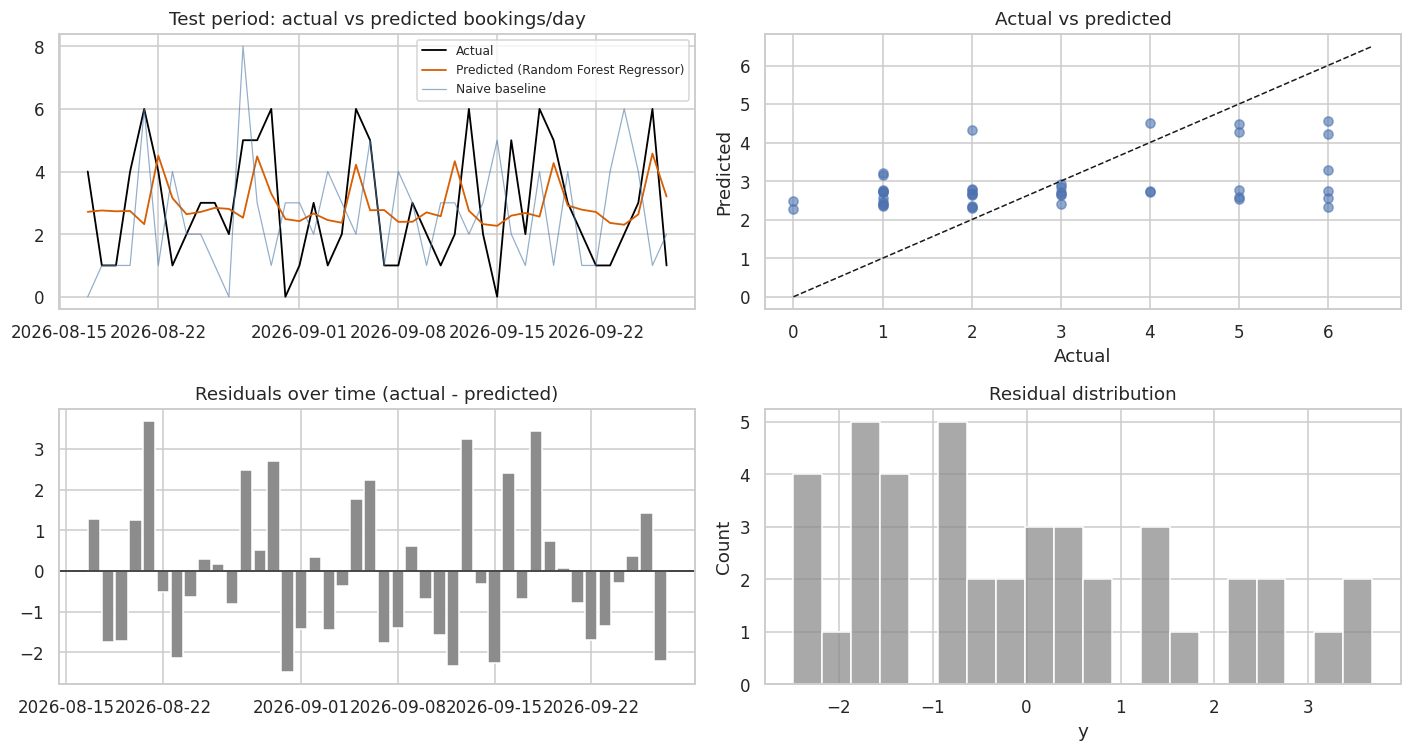

Residual mean (bias): -0.038 | residual std: 1.725 | lag-1 autocorrelation: -0.06

>> Finding: On the untouched test period the selected model's MAE is 1.42 bookings/day versus 1.56 for the best baseline ('Baseline: weekday mean'). The improvement is 9%, measured on 42 days, so treat it as indicative rather than proven.

Test period rolled up to months (partial months at the edges are incomplete):


,Actual,Predicted
Date,,
2026-08,47.00,44.69
2026-09,73.00,76.92


In [ ]:
if CAN_FORECAST:
    test_b, pred_b, beats_b = test_eval(ctx_b)
    print("FINAL TEST RESULTS (untouched test period):")
    display(test_b)
    yte = ctx_b["y"].iloc[ctx_b["n_train"]:]
    resid = yte - pred_b

    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    axes[0, 0].plot(yte.index, yte.values, label="Actual", color="black", lw=1.2)
    axes[0, 0].plot(yte.index, pred_b, label=f"Predicted ({ctx_b['selected']})", color="#d95f02", lw=1.2)
    axes[0, 0].plot(yte.index, ctx_b["lag"].iloc[ctx_b["n_train"]:].values, label="Naive baseline", color="#4c78a8", lw=0.8, alpha=0.6)
    axes[0, 0].set_title("Test period: actual vs predicted bookings/day"); axes[0, 0].legend(fontsize=8)
    axes[0, 1].scatter(yte, pred_b, alpha=0.6); lim = [0, max(yte.max(), pred_b.max()) + 0.5]
    axes[0, 1].plot(lim, lim, "k--", lw=1); axes[0, 1].set_xlabel("Actual"); axes[0, 1].set_ylabel("Predicted"); axes[0, 1].set_title("Actual vs predicted")
    axes[1, 0].bar(yte.index, resid.values, color="#8c8c8c", width=0.9); axes[1, 0].axhline(0, color="k", lw=1)
    axes[1, 0].set_title("Residuals over time (actual - predicted)")
    sns.histplot(resid, bins=20, ax=axes[1, 1], color="#8c8c8c"); axes[1, 1].set_title("Residual distribution")
    plt.tight_layout(); plt.show()

    ac1 = resid.autocorr(lag=1)
    print(f"Residual mean (bias): {resid.mean():.3f} | residual std: {resid.std():.3f} | lag-1 autocorrelation: {ac1:.2f}")
    msel = test_b.iloc[0]["MAE"]; bestb = test_b.iloc[1:].sort_values("MAE").iloc[0]
    if beats_b:
        finding(f"On the untouched test period the selected model's MAE is {msel:.2f} bookings/day versus {bestb['MAE']:.2f} for the best baseline "
                f"('{bestb['Model']}'). The improvement is {(1 - msel / bestb['MAE']):.0%}, measured on {len(yte)} days, so treat it as indicative rather than proven.")
    else:
        finding(f"The selected model (MAE {msel:.2f}) did NOT beat the best baseline ('{bestb['Model']}', MAE {bestb['MAE']:.2f}) on the test period. "
                "With the current data the model adds no demonstrated value over a simple rule, and its forecasts should not be relied on.")

    # monthly roll-up of the test period
    mt = pd.DataFrame({"Actual": yte, "Predicted": pred_b}).groupby(lambda d: d.to_period("M")).sum()
    print("\nTest period rolled up to months (partial months at the edges are incomplete):"); display(mt)
else:
    print("SKIPPED (CAN_FORECAST = False) - no forecasting model was trained.\n" + FORECAST_DEFERRED_MESSAGE)

### 11.1 Model interpretation (what did the model learn?)

* **Permutation importance** (computed on the test period) shows how much the MAE gets worse when one feature's values are shuffled. A large increase means the model relies on that feature.
* For Ridge Regression the standardised **coefficients** are also shown.
* These describe *what the model uses to predict*, i.e. **associations** in this dataset. They are not evidence that any feature *causes* bookings.

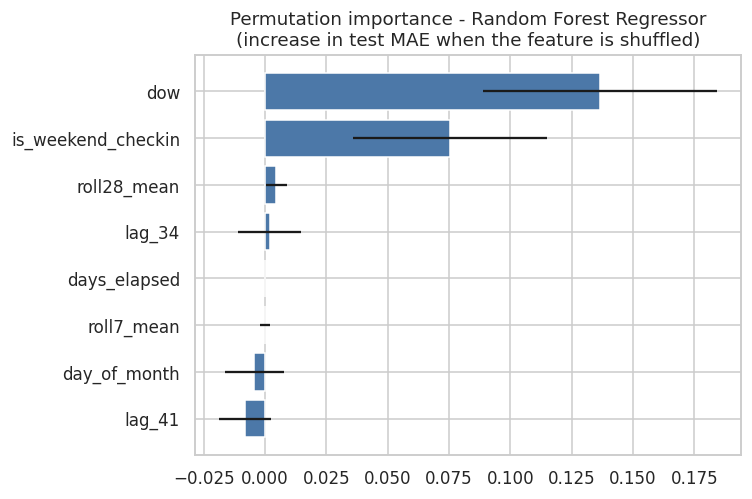


>> Finding: The features the selected model depends on most are: dow, is_weekend_checkin, roll28_mean. Features with near-zero importance are effectively ignored. This describes the model, not the business's causal drivers.

Note: fewer than 24 months of history, so month/week-of-year features were deliberately excluded; the model cannot claim to have learned seasonality.


In [ ]:
if CAN_FORECAST:
    model = ctx_b["tuned"][ctx_b["selected"]]
    Xte = ctx_b["X"].iloc[ctx_b["n_train"]:]; yte = ctx_b["y"].iloc[ctx_b["n_train"]:]
    pi = permutation_importance(model, Xte, yte, scoring="neg_mean_absolute_error", n_repeats=20, random_state=SEED)
    imp = pd.Series(pi.importances_mean, index=Xte.columns).sort_values()
    fig, ax = plt.subplots(figsize=(7, 0.4 * len(imp) + 1.5))
    ax.barh(imp.index, imp.values, xerr=pd.Series(pi.importances_std, index=Xte.columns)[imp.index].values, color="#4c78a8")
    ax.set_title(f"Permutation importance - {ctx_b['selected']}\n(increase in test MAE when the feature is shuffled)")
    plt.tight_layout(); plt.show()
    if ctx_b["selected"] == "Ridge Regression":
        coef = pd.Series(model.named_steps["model"].coef_, index=Xte.columns).sort_values()
        print("Standardised Ridge coefficients:"); display(coef.to_frame("coef"))
    top3 = list(imp.sort_values(ascending=False).index[:3])
    finding(f"The features the selected model depends on most are: {', '.join(top3)}. "
            "Features with near-zero importance are effectively ignored. This describes the model, not the business's causal drivers.")
    if not ctx_b["seasonal"]:
        print(f"\nNote: fewer than {MIN_MONTHS_SEASONAL} months of history, so month/week-of-year features were deliberately excluded; the model cannot claim to have learned seasonality.")
else:
    print("SKIPPED (CAN_FORECAST = False) - no model to interpret.")

# 12. Forecast Visualization

Once a model is selected and tested, it is **refitted on all usable history** (training + test) and used to forecast every day up to the end of the next calendar month, then summed into **monthly totals**.

* **Prediction intervals** are *empirical*: the 10th and 90th percentile of the model's out-of-fold validation errors (an approximate 80 % interval). They assume future errors resemble past errors.
* Weekly totals get an interval only if there are enough independent validation blocks; a whole-horizon total does not (too few independent blocks), so only a point estimate is shown.
* Negative predictions are shown as 0 (bookings cannot be negative).
* Forecasts are **estimates, not guaranteed future values**.

In [ ]:
# ------------------------- business chart helpers (used in Sections 12, 13.1 and 14) -------------------------
C_ACT, C_FC, C_BAR = "#2F5D8C", "#E8833A", "#2F5D8C"

def monthly_actual_forecast(actual_daily, fc_daily=None, avail_daily=None):
    # Month-by-month table. Actual = complete historical months. Forecast = months covered by the daily forecast
    # (if the last historical month is unfinished: actual so far + forecast for the remaining days).
    # avail_daily given -> values are percentages (occupied unit-nights / available unit-nights).
    pct = avail_daily is not None
    first, last = actual_daily.index.min(), actual_daily.index.max()
    has_fc = fc_daily is not None and len(fc_daily) > 0
    end = fc_daily.index.max() if has_fc else last
    rows = []
    for mth in pd.period_range(first.to_period("M"), end.to_period("M"), freq="M"):
        if mth in GAP_PERIODS:                      # month with no valid data: unknown, NOT zero
            rows.append((mth, np.nan, np.nan, "no data (month missing / invalid - not zero)")); continue
        days = pd.date_range(mth.start_time.normalize(), mth.end_time.normalize(), freq="D")
        hist_days = days[(days >= first) & (days <= last)]
        fc_days = days[days.isin(fc_daily.index)] if has_fc else days[:0]
        num = float(actual_daily.reindex(hist_days).sum()) + (float(fc_daily.reindex(fc_days).sum()) if len(fc_days) else 0.0)
        den = float(avail_daily.reindex(days).sum()) if pct else 1.0
        if pct and den <= 0:
            continue
        val = 100 * num / den if pct else num
        if len(fc_days) == 0 and len(hist_days) == len(days):
            rows.append((mth, val, np.nan, "actual"))
        elif len(fc_days) > 0 and len(hist_days) + len(fc_days) == len(days):
            rows.append((mth, np.nan, val, "forecast" if len(hist_days) == 0 else "month-to-date + forecast"))
        # months that are only partly known (e.g. a first month that starts mid-month) are left out of the chart
    return pd.DataFrame(rows, columns=["Month", "Actual", "Forecast", "Basis"]).set_index("Month")

def show_month_table(tbl, pct=False):
    f = (lambda v: "" if pd.isna(v) else f"{v:.1f}%") if pct else (lambda v: "" if pd.isna(v) else f"{v:,.0f}")
    out = tbl.copy()
    out.index = [m.strftime("%b %Y") for m in out.index]
    out["Actual"] = out["Actual"].map(f); out["Forecast"] = out["Forecast"].map(f)
    display(out)

def plot_monthly_line(tbl, title, ylabel, pct=False, caveat=None):
    if tbl is None or len(tbl) == 0 or tbl[["Actual", "Forecast"]].notna().sum().sum() == 0:
        print("Nothing to chart yet: at least one complete month of data is needed (upload more monthly files)."); return
    x = np.arange(len(tbl)); nodata = np.array([str(b).startswith("no data") for b in tbl["Basis"]])
    labels = [m.strftime("%b %Y") + ("\n(no data)" if nd_ else "") for m, nd_ in zip(tbl.index, nodata)]
    act, fc = tbl["Actual"], tbl["Forecast"]
    fmt = (lambda v: f"{v:.0f}%") if pct else (lambda v: f"{v:,.0f}")
    fig, ax = plt.subplots(figsize=(10, 4.6))
    if act.notna().any():
        ax.plot(x, act.values.astype(float), color=C_ACT, lw=2.4, marker="o", ms=6, label="Actual (historical)")
        for xi, v in zip(x[act.notna().values], act.dropna().values):
            ax.annotate(fmt(v), (xi, v), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=C_ACT)
    if fc.notna().any():
        fx, fy = list(x[fc.notna().values]), list(fc.dropna().values)
        px, py = list(fx), list(fy)
        if act.notna().any():                       # join the dashed line to the last actual point
            px, py = [x[act.notna().values][-1]] + fx, [act.dropna().values[-1]] + fy
        ax.plot(px, py, color=C_FC, lw=2.4, ls="--", marker="o", ms=6, mfc="white", label="Forecast (predicted)")
        for xi, v in zip(fx, fy):
            ax.annotate(fmt(v), (xi, v), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=C_FC, fontweight="bold")
        ax.axvspan(fx[0] - 0.5, x[-1] + 0.5, color=C_FC, alpha=0.07)
    top = np.nanmax(tbl[["Actual", "Forecast"]].values)
    ax.set_ylim(0, min(100, np.ceil(top * 1.3 / 10) * 10) if pct else top * 1.25 if top > 0 else 1)
    ax.set_xticks(x); rot = 45 if len(x) > 8 else 0
    ax.set_xticklabels(labels, rotation=rot, ha="right" if rot else "center")
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_ylabel(ylabel); ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.grid(axis="x", visible=False); ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22 if rot else -0.10), ncol=2)
    notes = []
    mtd = tbl.index[tbl["Basis"] == "month-to-date + forecast"]
    if len(mtd): notes.append(f"{mtd[0].strftime('%b %Y')} = actual so far + forecast for the remaining days.")
    if nodata.any(): notes.append("Gap = month with no valid data (not zero).")
    if caveat: notes.append(caveat)
    if notes:
        fig.text(0.01, 0.005, "  ".join(notes), fontsize=8, color="#666666", ha="left", va="bottom", wrap=True)
    fig.tight_layout(rect=(0, 0.04 if notes else 0, 1, 1)); plt.show()

def plot_unit_bars(s, title, ylabel, note=None):
    s = s.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(max(7.5, 0.95 * len(s) + 3), 4.5))
    bars = ax.bar([str(u).title() for u in s.index], s.values, color=C_BAR, width=0.62)
    ax.bar_label(bars, labels=[f"{v:,.0f}" for v in s.values], padding=3, fontsize=10)
    ax.set_ylim(0, max(s.max() * 1.18, 1)); ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.grid(axis="x", visible=False); ax.spines[["top", "right"]].set_visible(False)
    if len(s) > 6: plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    if note: fig.text(0.01, 0.005, note, fontsize=8, color="#666666", ha="left", va="bottom", wrap=True)
    fig.tight_layout(rect=(0, 0.05 if note else 0, 1, 1)); plt.show()

def units_available_daily(inv, start, end):
    # number of units that can be sold on each date, from an INVENTORY-style dict (None end = still available)
    idx = pd.date_range(start, end, freq="D"); cnt = pd.Series(0, index=idx, dtype=int)
    for _, (a, b) in inv.items():
        a = pd.Timestamp(a); b = pd.Timestamp(b) if b else pd.Timestamp(end)
        cnt[(idx >= a) & (idx <= b)] += 1
    return cnt


FORECAST STATUS: RELIABLE - the selected model beat the simple baselines on validation and on the untouched test period. 



,Actual,Forecast,Basis
Jan 2026,70,,actual
Feb 2026,77,,actual
Mar 2026,90,,actual
Apr 2026,144,,actual
May 2026,144,,actual
Jun 2026,118,,actual
Jul 2026,76,,actual
Aug 2026,90,,actual
Sep 2026,,80,month-to-date + forecast
Oct 2026,,88,forecast


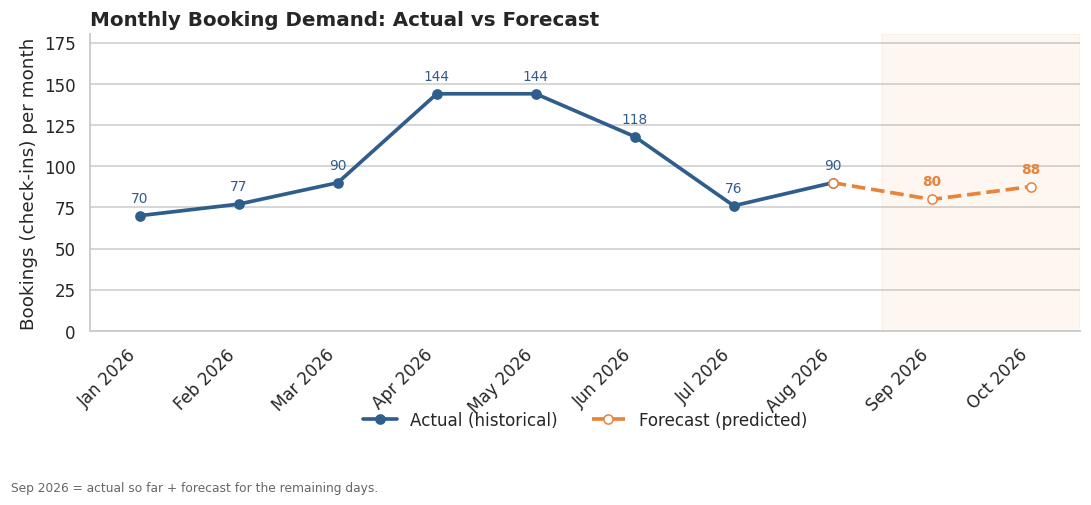


>> Finding: The model forecasts about 88 bookings (check-ins) in October 2026, compared with 90 in the last complete month (August 2026). On the test period the typical daily error was about 1.42 bookings, so monthly totals are estimates, not guarantees.

Weekly detail of the forecast (point estimates):


,Period,Days,Predicted total,Lower (80%),Upper (80%)
0,2026-09-28 to 2026-10-04,7,18.43,7.33,22.58
1,2026-10-05 to 2026-10-11,7,19.10,8.01,23.25
2,2026-10-12 to 2026-10-18,7,19.65,8.55,23.80
3,2026-10-19 to 2026-10-25,7,19.85,8.75,24.00
4,2026-10-26 to 2026-10-31,6,17.45,NaN,NaN
5,2026-09-28 to 2026-10-31 (whole horizon),34,94.47,NaN,NaN


Caution: the latest days in the data may not yet include stays that will be booked later, which can make recent counts look low.


In [ ]:
def make_forecast(ctx, y_daily, horizon=HORIZON_DAYS, block=7, lo_q=0.10, hi_q=0.90):
    fut_idx = pd.date_range(y_daily.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    F = build_features(pd.concat([y_daily, pd.Series(np.nan, index=fut_idx)]), horizon, ctx["seasonal"])
    Xf = F.loc[fut_idx, ctx["X"].columns]
    assert not Xf.isna().any().any(), "future features must be computable from known history only"
    final = clone(ctx["tuned"][ctx["selected"]]).fit(ctx["X"], ctx["y"])
    pred = final.predict(Xf)
    # out-of-fold validation residuals of the selected configuration (training data only)
    Xtr, ytr = ctx["X"].iloc[:ctx["n_train"]], ctx["y"].iloc[:ctx["n_train"]]
    fold_res = []
    for tr, va in ctx["splits"]:
        m = clone(ctx["tuned"][ctx["selected"]]).fit(Xtr.iloc[tr], ytr.iloc[tr])
        fold_res.append((ytr.iloc[va] - m.predict(Xtr.iloc[va])).values)
    r = np.concatenate(fold_res)
    dlo, dhi = np.quantile(r, [lo_q, hi_q])
    bl = [c[i:i + block].sum() for c in fold_res for i in range(0, len(c) - block + 1, block)]
    wq = np.quantile(bl, [lo_q, hi_q]) if len(bl) >= 10 else None
    daily = pd.DataFrame({"Predicted": np.clip(pred, 0, None), "Lower (80%)": np.clip(pred + dlo, 0, None),
                          "Upper (80%)": np.clip(pred + dhi, 0, None)}, index=fut_idx)
    rows = []
    for i in range(0, horizon, block):
        ch = daily.iloc[i:i + block]; tot = ch["Predicted"].sum(); full = len(ch) == block
        rows.append({"Period": f"{ch.index[0].date()} to {ch.index[-1].date()}", "Days": len(ch), "Predicted total": tot,
                     "Lower (80%)": max(0, tot + wq[0]) if (full and wq is not None) else np.nan,
                     "Upper (80%)": max(0, tot + wq[1]) if (full and wq is not None) else np.nan})
    rows.append({"Period": f"{daily.index[0].date()} to {daily.index[-1].date()} (whole horizon)", "Days": horizon,
                 "Predicted total": daily["Predicted"].sum(), "Lower (80%)": np.nan, "Upper (80%)": np.nan})
    return daily, pd.DataFrame(rows)

def plot_forecast(y_daily, daily_fc, title, ylabel, history_days=90):
    h = y_daily.iloc[-history_days:]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(h.index, h.values, color="black", lw=1, alpha=0.5, label="Historical (daily)")
    ax.plot(h.index, h.rolling(7).mean(), color="black", lw=2, label="Historical (7-day average)")
    ax.plot(daily_fc.index, daily_fc["Predicted"], color="#d95f02", lw=2, label="FORECAST (predicted)")
    ax.fill_between(daily_fc.index, daily_fc["Lower (80%)"], daily_fc["Upper (80%)"], color="#d95f02", alpha=0.2, label="Approx. 80% interval")
    ax.axvline(y_daily.index[-1], color="grey", ls="--"); ax.text(y_daily.index[-1], ax.get_ylim()[1] * 0.95, " forecast starts", va="top")
    ax.set_title(title); ax.set_ylabel(ylabel); ax.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

fc_b = fc_b_weeks = monthly_bk = None
fc_b_reliable = False
FORECAST_STATUS = "NOT RUN (forecasting deferred)"
if CAN_FORECAST:
    fc_b, fc_b_weeks = make_forecast(ctx_b, daily_bookings.astype(float))
    fc_b_reliable = bool(beats_b and ctx_b["cv_beats_baseline"]) and not EXPERIMENTAL_FORECAST
    FORECAST_STATUS = ("RELIABLE - the selected model beat the simple baselines on validation and on the untouched test period." if fc_b_reliable else
                       "EXPERIMENTAL / UNRELIABLE - the data has missing or invalid month(s) and ALLOW_MISSING_MONTHS = True." if EXPERIMENTAL_FORECAST else
                       "ILLUSTRATIVE ONLY - the selected model did not clearly beat the simple baselines.")
    print("FORECAST STATUS:", FORECAST_STATUS, "\n")
    if not fc_b_reliable:
        print("*** WARNING: the selected model did not clearly beat the simple baseline (validation and/or test). "
              "Treat the forecast below as illustrative only. ***\n")
    monthly_bk = monthly_actual_forecast(daily_bookings.astype(float), fc_b["Predicted"])
    show_month_table(monthly_bk)
    plot_monthly_line(monthly_bk, "Monthly Booking Demand: Actual vs Forecast", "Bookings (check-ins) per month",
                      caveat=None if fc_b_reliable else ("EXPERIMENTAL - unreliable (missing month present)." if EXPERIMENTAL_FORECAST else "Illustrative only: the model did not clearly beat the simple baseline."))
    fcm = monthly_bk[monthly_bk["Forecast"].notna()]; am = monthly_bk[monthly_bk["Actual"].notna()]
    msg = f"The model forecasts about {fcm['Forecast'].iloc[-1]:.0f} bookings (check-ins) in {fcm.index[-1].strftime('%B %Y')}"
    if len(am):
        msg += f", compared with {am['Actual'].iloc[-1]:.0f} in the last complete month ({am.index[-1].strftime('%B %Y')})"
    finding(msg + f". On the test period the typical daily error was about {test_b.iloc[0]['MAE']:.2f} bookings, so monthly totals are estimates, not guarantees.")
    print("\nWeekly detail of the forecast (point estimates):"); display(fc_b_weeks)
    if last_d < last_d + pd.offsets.MonthEnd(0):
        print("Caution: the latest days in the data may not yet include stays that will be booked later, which can make recent counts look low.")
else:
    print("SKIPPED (CAN_FORECAST = False) - no forecast produced.\n" + FORECAST_DEFERRED_MESSAGE + "\nHistorical demand is described in Sections 5-8.")


### 12.1 Optional: revenue forecast (OFF by default)

The ML paper forecasts **daily booking count only** and lists pricing / financial forecasting as out of scope, so this block runs only when `ENABLE_REVENUE_FORECAST = True` *and* `CAN_FORECAST` is True.

In [ ]:
ctx_r = test_r = fc_r = None
if not ENABLE_REVENUE_FORECAST:
    print("SKIPPED - revenue forecasting is switched OFF (ENABLE_REVENUE_FORECAST = False). The ML paper forecasts daily booking count only "
          "and lists pricing / financial forecasting as out of scope. Revenue is analysed descriptively in Section 8.")
elif CAN_FORECAST:
    daily_revenue = daily_series(dt, "Total Bill")
    ctx_r = prepare_daily(daily_revenue.astype(float), SEASONAL_OK)
    display(ctx_r["cv_table"].sort_values("CV MAE (mean)").reset_index(drop=True))
    test_r, pred_r, beats_r = test_eval(ctx_r)
    print("Test results - daily booked revenue (PHP):"); display(test_r)
    if beats_r and ctx_r["cv_beats_baseline"] and not EXPERIMENTAL_FORECAST:
        fc_r, fc_r_weeks = make_forecast(ctx_r, daily_revenue.astype(float))
        display(fc_r_weeks)
        plot_forecast(daily_revenue, fc_r, "Accommodation booked revenue per day: history vs forecast", "PHP per day")
    else:
        print("The selected revenue model does not clearly beat the simple baseline (or the run is experimental), so no revenue forecast is presented.")
else:
    print("SKIPPED (CAN_FORECAST = False) - " + FORECAST_DEFERRED_MESSAGE)

SKIPPED - revenue forecasting is switched OFF (ENABLE_REVENUE_FORECAST = False). The ML paper forecasts daily booking count only and lists pricing / financial forecasting as out of scope. Revenue is analysed descriptively in Section 8.


# 13. Optional Unit-Level Forecasting

Runs only if `CAN_UNIT_FORECAST` is True: at least 40 complete weeks of history (weeks inside a missing month do not count) and at least two of the **10 accommodation units** with 20+ bookings. Units with fewer bookings are **not** modelled (too little evidence).

**Approach:** one *global* model with the unit as a feature, on a **weekly** unit-by-week table (daily unit-level counts are almost all zeros). Same three algorithms, same chronological 80/20 split, time-ordered validation, baselines, and leakage rule (lags shifted by at least the 4-week horizon). Network-wide bookings from 4+ weeks earlier are included as a feature; this is available at forecast time.

In [ ]:
ctx_u = test_u = fc_u_tbl = unit_fc_period = None
if CAN_UNIT_FORECAST:
    HW = UNIT_HORIZON_WEEKS
    assert set(eligible_units) <= set(ACCOMMODATION_UNITS)
    d = dt[dt["Unit ID"].isin(eligible_units)].copy()
    d["Week"] = d["Check-In Date"].dt.to_period("W-SUN").dt.start_time
    weeks = pd.date_range(first_full_mon, last_full_sun - pd.Timedelta(days=6), freq="7D")
    counts = d.groupby(["Week", "Unit ID"]).size().rename_axis(["Week", "Unit"])
    panel = counts.reindex(pd.MultiIndex.from_product([weeks, eligible_units], names=["Week", "Unit"]), fill_value=0).rename("y").reset_index()
    if len(weeks_with_gap):                                      # weeks inside a month with no data are UNKNOWN, not zero
        panel.loc[panel["Week"].isin(weeks_with_gap), "y"] = np.nan
    fut_weeks = pd.date_range(weeks[-1] + pd.Timedelta(weeks=1), periods=HW, freq="7D")
    fut = pd.MultiIndex.from_product([fut_weeks, eligible_units], names=["Week", "Unit"]).to_frame(index=False); fut["y"] = np.nan
    p = pd.concat([panel, fut], ignore_index=True).sort_values(["Unit", "Week"]).reset_index(drop=True)
    g = p.groupby("Unit")["y"]
    p[f"lag_{HW}"] = g.shift(HW); p[f"lag_{HW+1}"] = g.shift(HW + 1)
    p["roll4_mean"] = g.transform(lambda s: s.shift(HW).rolling(4).mean())
    net = p.groupby("Week")["y"].sum(min_count=1).sort_index()
    p["net_lag"] = p["Week"].map(net.shift(HW))
    p["weeks_elapsed"] = (p["Week"] - p["Week"].min()).dt.days // 7
    if SEASONAL_OK: p["month"] = p["Week"].dt.month
    p = pd.concat([p, pd.get_dummies(p["Unit"], prefix="unit", dtype=int)], axis=1).sort_values(["Week", "Unit"]).reset_index(drop=True)
    fcols = [c for c in p.columns if c.startswith("unit_")] + ["weeks_elapsed", f"lag_{HW}", f"lag_{HW+1}", "roll4_mean", "net_lag"] + (["month"] if SEASONAL_OK else [])
    hist = p[p["y"].notna()].dropna(subset=fcols).reset_index(drop=True)

    wk_all = np.sort(hist["Week"].unique()); n_test_w = int(round(len(wk_all) * TEST_FRACTION))
    train_weeks = wk_all[:-n_test_w]; n_train = int(hist["Week"].isin(train_weeks).sum())
    wk_rows = hist["Week"].values[:n_train]; splits = []
    for a, b in TimeSeriesSplit(n_splits=CV_SPLITS).split(train_weeks):
        splits.append((np.where(np.isin(wk_rows, train_weeks[a]))[0], np.where(np.isin(wk_rows, train_weeks[b]))[0]))
    ctx_u = fit_and_select(hist[fcols], hist["y"], hist["Unit"], hist[f"lag_{HW}"], n_train, splits, "unit", f"{HW} weeks")
    print(f"Units modelled: {eligible_units}\nComplete weeks used: {len(wk_all)} | train weeks: {len(train_weeks)} | test weeks: {n_test_w}")
    display(ctx_u["cv_table"].sort_values("CV MAE (mean)").reset_index(drop=True))
    test_u, pred_u, beats_u = test_eval(ctx_u)
    print("Final test results (bookings per unit per week):"); display(test_u)
    te = hist.iloc[n_train:].assign(Pred=pred_u)
    per_unit = te.groupby("Unit").apply(lambda x: pd.Series({"Test MAE": mean_absolute_error(x["y"], x["Pred"]),
                                                             "Mean actual": x["y"].mean(), "Mean predicted": x["Pred"].mean()}))
    display(per_unit)
    if beats_u and ctx_u["cv_beats_baseline"]:
        final = clone(ctx_u["tuned"][ctx_u["selected"]]).fit(ctx_u["X"], ctx_u["y"])
        fut_rows = p[p["Week"].isin(fut_weeks)]
        assert not fut_rows[fcols].isna().any().any()
        fut_rows = fut_rows.assign(Predicted=np.clip(final.predict(fut_rows[fcols]), 0, None))
        fc_u_tbl = fut_rows.pivot(index="Unit", columns="Week", values="Predicted")
        fc_u_tbl.columns = [f"week of {c.date()}" for c in fc_u_tbl.columns]; fc_u_tbl["Total (4 weeks)"] = fc_u_tbl.sum(axis=1)
        unit_fc_period = (fut_weeks[0], fut_weeks[-1] + pd.Timedelta(days=6))
        print("Forecast: expected bookings per unit (point estimates, no interval):"); display(fc_u_tbl)
    else:
        print("The unit-level model does not clearly beat the simple baseline, so no unit forecast is presented.")
else:
    if not CAN_FORECAST:
        print("SKIPPED (CAN_FORECAST = False) - " + FORECAST_DEFERRED_MESSAGE)
    else:
        print("SKIPPED (CAN_UNIT_FORECAST = False) - unit-level forecasting is not feasible with the current data "
              f"({n_full_weeks} complete weeks without gaps; {len(eligible_units)} accommodation unit(s) with >= {MIN_UNIT_BOOKINGS} bookings). "
              "Section 13.1 will show the overall forecast ALLOCATED by recent booking share, clearly labelled as an allocation.")
        print(f"\nAdditional history needed: at least {MIN_UNIT_WEEKS} complete weeks and >= {MIN_UNIT_BOOKINGS} bookings per unit.")
    print("\nBookings per accommodation unit (valid dates; descriptive only - units under the threshold are never modelled):")
    display(unit_bookings.sort_values(ascending=False).to_frame("Bookings"))

SKIPPED (CAN_UNIT_FORECAST = False) - unit-level forecasting is not feasible with the current data (38 complete weeks without gaps; 8 accommodation unit(s) with >= 20 bookings). Section 13.1 will show the overall forecast ALLOCATED by recent booking share, clearly labelled as an allocation.

Additional history needed: at least 40 complete weeks and >= 20 bookings per unit.

Bookings per accommodation unit (valid dates; descriptive only - units under the threshold are never modelled):


,Bookings
Unit ID,
MATILDA,127
MARGARET,121
ELIZABETH,115
JULIANA,113
GABRIEL,110
VICTORIA,109
ELEANOR,92
DIANA,91
LEA,3


### 13.1 Predicted demand by accommodation unit (bar chart - the 10 units only)

If the unit-level model above ran and beat its baseline, its forecast is used (units with 20+ bookings only). Otherwise the **overall booking forecast is split across the 10 units in proportion to each unit's share of bookings over the last `UNIT_SHARE_DAYS` days** - a transparent **allocation, not an independent unit forecast**, and labelled as such on the chart and table. Months with no data are skipped when computing shares. Units are not adjusted for how long each was available. If the overall forecast is deferred, there is nothing to allocate and the cell says so.

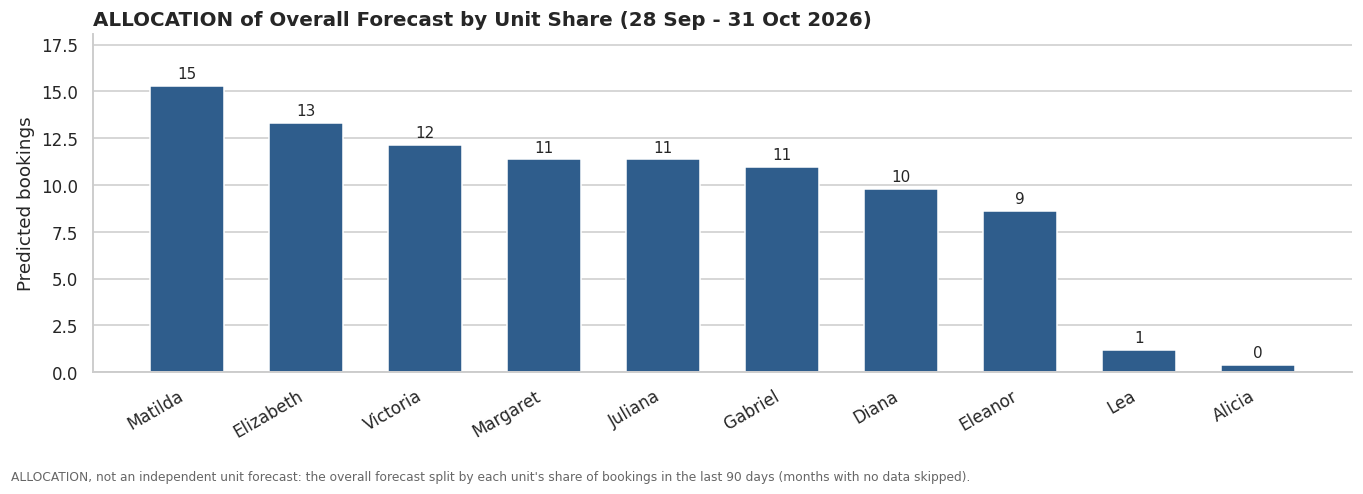

,Predicted bookings,Share of total,Location,Category,Basis
Unit ID,,,,,
MATILDA,15.30,16.2%,Shore Residence (Pasay),Direct To Pool,allocation of overall forecast
ELIZABETH,13.30,14.1%,Shore Residence (Pasay),Direct To Pool,allocation of overall forecast
VICTORIA,12.20,12.9%,Shore Residence (Pasay),Direct To Pool,allocation of overall forecast
MARGARET,11.40,12.0%,Shore Residence (Pasay),Direct To Pool,allocation of overall forecast
JULIANA,11.40,12.0%,Shore Residence (Pasay),Direct To Pool,allocation of overall forecast
GABRIEL,11.00,11.6%,Shore Residence (Pasay),Family Suites,allocation of overall forecast
DIANA,9.80,10.4%,Shore Residence (Pasay),Family Suites,allocation of overall forecast
ELEANOR,8.60,9.1%,Shore Residence (Pasay),Family Suites,allocation of overall forecast
LEA,1.20,1.2%,Fame Residence (Mandaluyong),Not specified,allocation of overall forecast



>> Finding: MATILDA is expected to receive the most bookings (~15) and ALICIA the fewest (~0) in 28 Sep - 31 Oct 2026 (ALLOCATION of the overall forecast, not an independent unit forecast). Differences reflect past demand per unit and are not adjusted for availability.


In [ ]:
unit_pred = None
all_units = list(ACCOMMODATION_UNITS)                      # the 10 accommodation units - never parking / add-ons
unit_chart_kind = None
if fc_u_tbl is not None:
    unit_pred = fc_u_tbl["Total (4 weeks)"].reindex(all_units).dropna()
    period = f"{unit_fc_period[0]:%d %b} - {unit_fc_period[1]:%d %b %Y}"
    title = f"Predicted Bookings per Accommodation Unit ({period})"
    note = (f"Independent unit-level model (Ridge / Random Forest / Gradient Boosting). Only units with >= {MIN_UNIT_BOOKINGS} bookings are modelled "
            f"({len(unit_pred)} of 10 shown).")
    unit_chart_kind = "unit-level model"
elif fc_b is not None:
    recent = dt[(dt["Check-In Date"] > last_d - pd.Timedelta(days=UNIT_SHARE_DAYS)) & ~dt["Check-In Month"].isin(list(GAP_PERIODS))]
    share = recent["Unit ID"].value_counts(normalize=True).reindex(all_units, fill_value=0)
    unit_pred = share * fc_b["Predicted"].sum()
    period = f"{fc_b.index[0]:%d %b} - {fc_b.index[-1]:%d %b %Y}"
    title = f"ALLOCATION of Overall Forecast by Unit Share ({period})"
    note = (f"ALLOCATION, not an independent unit forecast: the overall forecast split by each unit's share of bookings in the last {UNIT_SHARE_DAYS} days "
            "(months with no data skipped)." + ("" if fc_b_reliable else " Illustrative only: the overall forecast is not reliable."))
    unit_chart_kind = "allocation"
if unit_pred is not None:
    assert set(unit_pred.index) <= set(ACCOMMODATION_UNITS), "non-accommodation unit reached the unit chart"
    plot_unit_bars(unit_pred, title, "Predicted bookings", note)
    tbl_u = unit_pred.sort_values(ascending=False).to_frame("Predicted bookings")
    tbl_u["Share of total"] = (tbl_u["Predicted bookings"] / tbl_u["Predicted bookings"].sum() * 100).round(1).astype(str) + "%"
    tbl_u["Predicted bookings"] = tbl_u["Predicted bookings"].round(1)
    tbl_u["Location"] = [UNIT_LOCATION[u] for u in tbl_u.index]; tbl_u["Category"] = [UNIT_CATEGORY[u] for u in tbl_u.index]
    tbl_u["Basis"] = "independent unit-level forecast" if unit_chart_kind == "unit-level model" else "allocation of overall forecast"
    display(tbl_u)
    finding(f"{tbl_u.index[0]} is expected to receive the most bookings (~{unit_pred.max():.0f}) and {tbl_u.index[-1]} the fewest (~{unit_pred.min():.0f}) "
            f"in {period} ({'unit-level model' if unit_chart_kind == 'unit-level model' else 'ALLOCATION of the overall forecast, not an independent unit forecast'}). "
            "Differences reflect past demand per unit and are not adjusted for availability.")
else:
    print("SKIPPED - " + (FORECAST_DEFERRED_MESSAGE if not CAN_FORECAST else "no overall forecast is available") + " There is no forecast to compare across units. "
          "Descriptive demand for the 10 units is in Section 7.")

# 14. Occupancy Analysis and Monthly Occupancy Forecast

**Occupancy = booked unit-nights / available unit-nights.** The numerator is counted from the data. The denominator needs to know **which of the 10 accommodation units existed and when each was available**, which booking records alone cannot show (empty units, maintenance, units added later).

* **Preferred:** fill in `INVENTORY` (Section 2.1) with real availability dates.
* **Otherwise**, if `ASSUME_UNITS_AVAILABLE = True`, the notebook **estimates** occupancy by assuming each of the **10 accommodation units** can be sold every day from the first day of the month of its first booking (units without bookings: from the first data month). Parking and add-on rows are never counted. Every chart and table is then labelled *estimated*. If units were blocked on some days the true occupancy is higher than the estimate; if a unit existed before its first booking the estimate may be too high. Set `ASSUME_UNITS_AVAILABLE = False` to switch occupancy off.

The forecast uses the same method, gates and three algorithms as booking demand (daily occupied units, summed to months).

Days in a month with no valid data are excluded from the denominator and shown as gaps - they are not treated as 0 % occupancy.

Inventory basis: ESTIMATED / ASSUMED (each of the 10 units sellable every day from the month of its first booking; units without bookings from the first data month) | units in the denominator: 10 (parking and add-on rows are never counted)
Occupancy by accommodation unit (estimated):


,Available_unit_nights,Booked_unit_nights,Estimated occupancy %
Unit ID,,,
VICTORIA,270,159.00,58.89
MATILDA,270,144.00,53.33
ELIZABETH,270,142.00,52.59
GABRIEL,270,135.00,50.00
JULIANA,270,133.00,49.26
MARGARET,270,130.00,48.15
ELEANOR,270,118.00,43.70
DIANA,270,116.00,42.96
LEA,89,3.00,3.37


Validation results (daily occupied units):


,Model,Type,CV MAE (mean),CV MAE (std),CV RMSE (mean),CV R2 (mean),Tuned parameters
0,Gradient Boosting Regressor,Algorithm,1.53,0.44,1.90,-0.22,"{'learning_rate': 0.03, 'max_depth': 2, 'n_est..."
1,Random Forest Regressor,Algorithm,1.67,0.47,2.02,-0.39,"{'max_depth': 8, 'min_samples_leaf': 3, 'n_est..."
2,Ridge Regression,Algorithm,1.79,0.43,2.20,-0.71,{'model__alpha': 100}
3,Baseline: weekday mean,Baseline,1.81,0.26,2.20,-0.80,-
4,Baseline: training mean,Baseline,1.85,0.37,2.18,-0.73,-
5,Baseline: naive (value 34 days earlier),Baseline,2.41,0.27,3.01,-2.35,-


Test results:


,Model,MAE,RMSE,WAPE,R2
0,Gradient Boosting Regressor (selected),1.71,2.10,0.46,0.11
1,Baseline: training mean,2.09,2.33,0.57,-0.10
2,Baseline: weekday mean,1.78,2.09,0.48,0.12
3,Baseline: naive (value 34 days earlier),2.48,2.95,0.67,-0.77


,Actual,Forecast,Basis
Jan 2026,39.9%,,actual
Feb 2026,39.7%,,actual
Mar 2026,40.7%,,actual
Apr 2026,69.6%,,actual
May 2026,71.4%,,actual
Jun 2026,60.4%,,actual
Jul 2026,33.7%,,actual
Aug 2026,37.1%,,actual
Sep 2026,,34.5%,month-to-date + forecast
Oct 2026,,34.3%,forecast


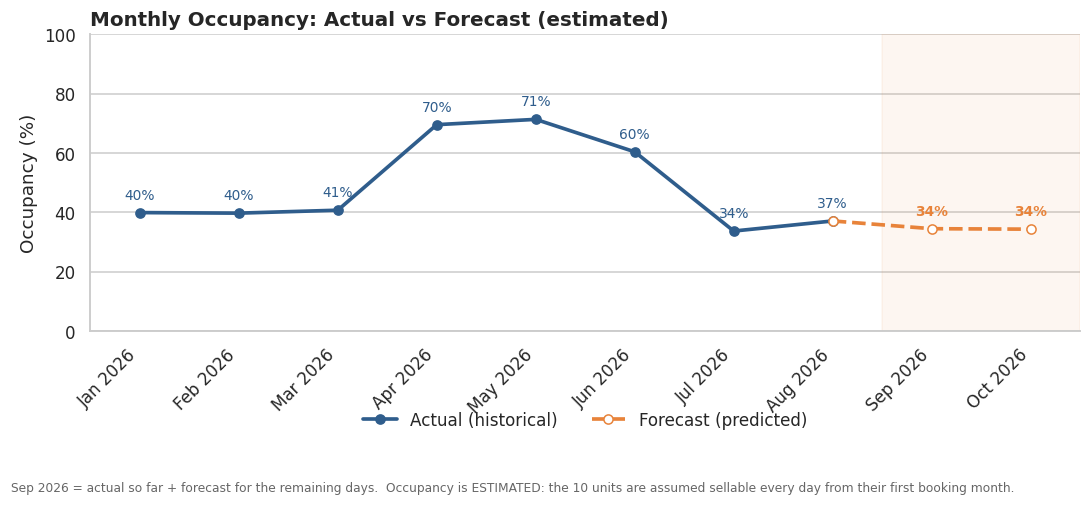


>> Finding: Estimated occupancy is forecast at about 34% for October 2026, versus 37% in the last complete month. Forecast occupancy is an estimate based on booked unit-nights and the inventory basis stated above.


In [ ]:
occ_fc = None
EST_TAG = "" if INVENTORY is not None else " (ESTIMATED)"
if not CAN_OCC:
    print("Occupancy is not calculated: no inventory was provided and ASSUME_UNITS_AVAILABLE is False.\n")
    display(pd.DataFrame({
        "Additional field needed": ["Availability start date per accommodation unit (opening / listing date)",
                                    "Availability end date or blocked periods (maintenance, owner use, closures)", "Capacity per unit (optional, for guest-based utilisation)"],
        "Why it is needed": ["Avoids counting nights before a unit existed", "Avoids counting nights the unit could not be sold", "Separates small units from large ones"]}))
    print("What CAN be stated from the data (booked unit-nights of the 10 accommodation units, not occupancy):")
    display(nights_tbl.groupby("Unit ID").size().reindex(ACCOMMODATION_UNITS, fill_value=0).sort_values(ascending=False).to_frame("Booked unit-nights"))
else:
    print("Inventory basis:", INV_SOURCE, "| units in the denominator:", len(INV), "(parking and add-on rows are never counted)")
    est = "" if INVENTORY is not None else "estimated "
    inv = {u: (pd.Timestamp(a), pd.Timestamp(b) if b else last_d) for u, (a, b) in INV.items()}
    missing_units = sorted(set(dt["Unit ID"].dropna()) - set(inv))
    if missing_units:
        raise ValueError(f"INVENTORY must list every accommodation unit that has bookings; missing: {missing_units}")
    win = pd.date_range(first_d, last_d, freq="D")
    gap_day = np.asarray(win.to_period("M").isin(list(GAP_PERIODS)))       # months with no data are NOT sellable-and-empty days: they are unknown
    sell_days = win[~gap_day]
    avail = pd.DataFrame([(u, dte) for u, (a, b) in inv.items() for dte in sell_days if a <= dte <= b], columns=["Unit ID", "Date"])
    booked = nights_tbl[["Unit ID", "Night Date"]].drop_duplicates().rename(columns={"Night Date": "Date"}).assign(Booked=1)
    booked = booked[(booked["Date"] >= first_d) & (booked["Date"] <= last_d) & booked["Date"].isin(sell_days)]
    m = avail.merge(booked, on=["Unit ID", "Date"], how="left").fillna({"Booked": 0})
    outside = len(booked) - int(m["Booked"].sum())
    if outside: print(f"Warning: {outside} booked unit-nights fall outside the inventory availability windows.")
    occ_unit = m.groupby("Unit ID").agg(Available_unit_nights=("Booked", "size"), Booked_unit_nights=("Booked", "sum"))
    occ_unit["Estimated occupancy %" if est else "Occupancy %"] = 100 * occ_unit["Booked_unit_nights"] / occ_unit["Available_unit_nights"]
    assert set(occ_unit.index) <= set(ACCOMMODATION_UNITS)
    print(f"Occupancy by accommodation unit ({est.strip() or 'actual'}):"); display(occ_unit.sort_values(occ_unit.columns[-1], ascending=False))

    occ_daily = m.groupby("Date")["Booked"].sum().reindex(win).astype(float)             # NaN on days of months with no data
    avail_all = units_available_daily(INV, first_d, fc_target_end)                       # sellable units per day (incl. future)
    avail_all[np.asarray(avail_all.index.to_period("M").isin(list(GAP_PERIODS)))] = 0
    fc_o_daily = None
    caveat = (None if INVENTORY is not None else "Occupancy is ESTIMATED: the 10 units are assumed sellable every day from their first booking month.")
    if EXPERIMENTAL_FORECAST:
        caveat = ((caveat + " ") if caveat else "") + "EXPERIMENTAL: missing month(s) present - unreliable."

    if CAN_OCC_FORECAST:
        ctx_o = prepare_daily(occ_daily, SEASONAL_OK)
        print("Validation results (daily occupied units):"); display(ctx_o["cv_table"].sort_values("CV MAE (mean)").reset_index(drop=True))
        test_o, pred_o, beats_o = test_eval(ctx_o); print("Test results:"); display(test_o)
        fc_o, _ = make_forecast(ctx_o, occ_daily)
        fc_o_daily = pd.Series(np.minimum(fc_o["Predicted"].values, avail_all.reindex(fc_o.index).values), index=fc_o.index)
        if not (beats_o and ctx_o["cv_beats_baseline"]) or EXPERIMENTAL_FORECAST:
            print("*** WARNING: the occupancy forecast is ILLUSTRATIVE only (model did not clearly beat the simple baseline, or the run is experimental). ***")
            caveat = ((caveat + " ") if caveat else "") + "Forecast is illustrative, not reliable."
    else:
        print("Occupancy FORECAST skipped (CAN_OCC_FORECAST = False): " + (FORECAST_DEFERRED_MESSAGE or "see Section 9") + " Only actual occupancy is charted.")

    occ_fc = monthly_actual_forecast(occ_daily, fc_o_daily, avail_daily=avail_all)
    show_month_table(occ_fc, pct=True)
    plot_monthly_line(occ_fc, "Monthly Occupancy: Actual vs Forecast" + (" (estimated)" if est else ""), "Occupancy (%)", pct=True, caveat=caveat)
    fm = occ_fc[occ_fc["Forecast"].notna()]
    if len(fm):
        finding(f"{est.capitalize()}occupancy is forecast at about {fm['Forecast'].iloc[-1]:.0f}% for {fm.index[-1].strftime('%B %Y')}"
                + (f", versus {occ_fc['Actual'].dropna().iloc[-1]:.0f}% in the last complete month." if occ_fc['Actual'].notna().any() else ".")
                + " Forecast occupancy is an estimate based on booked unit-nights and the inventory basis stated above.")

# 15. Results and Interpretation

The text below is generated from the results above, so it always matches the data currently loaded.

In [ ]:
def line(t=""): print(t)
n_files = len(file_log)
line("1. DATASET FINDINGS")
line(f"   {len(df_all)} validated records from {n_files} file(s). Scope: {len(df_accom)} accommodation records (the 10 units); {len(df_non_accom)} parking / add-on / other rows are excluded from demand, unit, occupancy and forecasting.")
line(f"   {len(dt)} accommodation bookings have a valid check-in date ({first_d.date()} to {last_d.date()}); {n_months} month(s) have data across a {n_month_span}-month span.")
if gap_months: line(f"   Month(s) with NO valid data: {', '.join(gap_months)} (missing or invalid workbook) - shown as 'no data', never as zero demand.")
if thin_months: line(f"   Month(s) far below the others (probably incomplete): {', '.join(thin_months)}.")
if unrecovered_files: line(f"   Workbook(s) with unrecoverable check-in dates: {', '.join(unrecovered_files)}.")
line("   Data-quality exclusions: " + "; ".join(f"{r['Data-quality step'].split(':')[0].strip()} {r['Data-quality step'].split(':',1)[1].strip() if ':' in r['Data-quality step'] else ''} = {r['Rows']}"
     for _, r in exclusions_df.iloc[2:10].iterrows() if r["Rows"] > 0 and r["Data-quality step"].startswith(("Excluded", "Flagged"))) + ".")
flagged = issues_df[(issues_df["Records"] > 0) & ~issues_df["Action taken"].str.startswith("None")]
for _, r in flagged.iterrows():
    line(f"   - {r['Check']}: {r['Records']} record(s). {r['Action taken']}.")
line("\n2. BOOKING TREND FINDINGS")
line(f"   {summary['Total booked nights']} nights were booked; average stay {summary['Average nights per booking']:.2f} nights, average party {summary['Average pax per booking']:.1f} guests, "
     f"{summary['Mean check-ins per calendar day (days with data)']:.2f} check-ins per calendar day (days with data).")
line(f"   Friday+Saturday check-ins are {dt['Weekend Check-In'].mean():.0%} of dated accommodation bookings (an observed pattern under the Fri/Sat assumption).")
line("   Month-to-month trend: " + ("not assessable (single month)." if n_months < 2 else f"shown descriptively across {n_months} months with data; " + ("a trend statistic was computed." if n_months >= MIN_MONTHS_TREND_STAT else "too few months to call a trend.")))
line("\n3. UNIT DEMAND FINDINGS (10 accommodation units only)")
line(f"   {hi} received the most bookings ({int(unit.loc[hi,'Bookings'])}) and {lo} the fewest with any booking ({int(unit.loc[lo,'Bookings'])}); counts are not adjusted for availability.")
line(f"   Units eligible for unit-level modelling (>= {MIN_UNIT_BOOKINGS} bookings): {len(eligible_units)} of 10.")
line("\n4. REVENUE FINDINGS")
line(f"   TOTAL booked revenue (all records) PHP {rev_tbl.iloc[0,2]:,.0f} | ACCOMMODATION-only PHP {rev_tbl.iloc[1,2]:,.0f} | ADD-ON / PARKING / service PHP {rev_tbl.iloc[2,2]:,.0f} | other out-of-scope PHP {rev_tbl.iloc[3,2]:,.0f}.")
line(f"   Accommodation: PHP {rev['Average revenue per accommodation booking (PHP)']:,.0f} per booking, PHP {rev['Revenue per booked accommodation night (PHP)']:,.0f} per booked night; "
     f"largest revenue share {top_units.index[0]} ({top_units.iloc[0]:.0%}). This is booked value, not cash collected.")
line("\n5. FORECASTING FINDINGS")
line(f"   Flags: CAN_FORECAST={CAN_FORECAST}, CAN_UNIT_FORECAST={CAN_UNIT_FORECAST}, CAN_OCC={CAN_OCC}, CAN_OCC_FORECAST={CAN_OCC_FORECAST}.")
if CAN_FORECAST:
    line(f"   Status: {FORECAST_STATUS}")
    line(f"   Selected algorithm: {ctx_b['selected']}. Forecast for the next {HORIZON_DAYS} days: ~{fc_b['Predicted'].sum():.0f} bookings (point estimate).")
    for mth, r_ in monthly_bk[monthly_bk["Forecast"].notna()].iterrows():
        line(f"   - {mth.strftime('%b %Y')}: ~{r_['Forecast']:.0f} bookings ({r_['Basis']}).")
    if occ_fc is not None and occ_fc["Forecast"].notna().any():
        for mth, r_ in occ_fc[occ_fc["Forecast"].notna()].iterrows():
            line(f"   - {mth.strftime('%b %Y')}: ~{r_['Forecast']:.0f}% occupancy ({'estimated, ' if INVENTORY is None else ''}{r_['Basis']}).")
else:
    line("   Not performed. " + FORECAST_DEFERRED_MESSAGE + " No future values are claimed.")
line("\n6. MODEL EVALUATION")
if CAN_FORECAST:
    line(f"   Test MAE = {test_b.iloc[0]['MAE']:.2f} bookings/day (RMSE {test_b.iloc[0]['RMSE']:.2f}, WAPE {test_b.iloc[0]['WAPE']:.0%}, R2 {test_b.iloc[0]['R2']:.2f}); best baseline MAE = {test_b.iloc[1:]['MAE'].min():.2f}.")
    unit_state = "deferred" if not CAN_UNIT_FORECAST else ("independent forecast presented" if fc_u_tbl is not None else "run, but no forecast shown (did not beat baseline)")
    if not CAN_UNIT_FORECAST and fc_b is not None: unit_state += "; the unit bar chart is an ALLOCATION of the overall forecast by recent booking share"
    rev_state = "off by default (paper forecasts booking count only)" if not ENABLE_REVENUE_FORECAST else ("forecast presented" if fc_r is not None else "run, but no forecast shown")
    line(f"   Unit-level forecasting: {unit_state}; revenue forecasting: {rev_state}; occupancy: {('ESTIMATED on assumed inventory' if INVENTORY is None else 'computed on real inventory') if CAN_OCC else 'not calculable (no inventory)'}.")
else:
    line("   No model was trained, so there are no model performance figures. Accuracy is not claimed.")
line("\n7. LIMITATIONS -> see Section 16.")
line("\n8. RECOMMENDED ADDITIONAL DATA")
need = []
if problem_months or unrecovered_files: need.append("the corrected / missing monthly workbook(s) listed above (real check-in dates inside the valid range)")
if n_month_span < 12: need.append(f"more monthly files - currently {n_month_span} month(s) spanned; at least 12 months (Jan-Dec) for a stable forecasting experiment, and 24+ to study seasonality")
if not CAN_OCC or INVENTORY is None: need.append("confirmed unit inventory with availability / blocked dates (occupancy is only an estimate until then)")
need += ["booking-creation (reservation) date, to study lead time and to forecast from bookings already on hand",
         "cancellations and no-shows (currently only completed/recorded bookings appear)",
         "price rules, promotions, and rate changes over time", "local events, holidays, and school breaks (external demand drivers)"]
for n in need: line("   - " + n)

1. DATASET FINDINGS
   953 validated records from 9 file(s). Scope: 890 accommodation records (the 10 units); 63 parking / add-on / other rows are excluded from demand, unit, occupancy and forecasting.
   882 accommodation bookings have a valid check-in date (2026-01-01 to 2026-09-27); 9 month(s) have data across a 9-month span.
   Data-quality exclusions: Excluded MISSING Unit ID = 1; Excluded NON-accommodation Unit ID - add-on / parking / service rows = 43; Excluded NON-accommodation Unit ID - other out-of-scope labels = 19; Excluded by INVALID DATE check-in missing / unparseable = 6; Excluded by NIGHTS issue Nights missing or < 1 = 2; Flagged by PAX issue Pax missing or < 1 (Pax is not used in the booking count) = 9.
   - Duplicate stays (same unit, dates, nights, pax, bill): 4 record(s). Removed (first occurrence kept).
   - Booking IDs reused across monthly files (distinct IDs): 153 record(s). Expected - each monthly file restarts at B0001; rows kept apart by Record ID.
   - Missi

# 16. Limitations

In [ ]:
if n_month_span < 12:
    bar = "!" * 100
    print(bar)
    print(f"MAJOR LIMITATION: the loaded data covers only {n_month_span} calendar month(s) ({first_d.date()} to {last_d.date()}).")
    print("A single season/period cannot reveal yearly seasonality or a long-run trend, and it leaves no history to train and test a forecast.")
    print(bar)
else:
    print(f"The loaded data covers {n_month_span} month(s). This is enough for a first forecasting experiment but still only "
          f"{'one annual cycle' if n_month_span < 24 else 'a limited number of annual cycles'}.")

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
MAJOR LIMITATION: the loaded data covers only 9 calendar month(s) (2026-01-01 to 2026-09-27).
A single season/period cannot reveal yearly seasonality or a long-run trend, and it leaves no history to train and test a forecast.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


* **Scope.** Only the 10 accommodation units are analysed. Parking, decor, airport pick-up, massage and similar rows are add-ons / billing rows: they appear only in the separate revenue split and the exclusions table.
* **Dataset size and time span.** Forecasting quality depends on history. Short histories give unstable models and test sets of only a few weeks; metrics on such test sets are indicative, not conclusive.
* **Invalid or missing months.** Check-in dates outside `VALID_START` ... `VALID_END` (e.g. 1970 epoch dates from numbers read as dates) are excluded and logged; dates are never inferred from a file name. A month with no valid data is shown as *no data*, never as zero, and forecasting is deferred until the workbook is corrected (`ALLOW_MISSING_MONTHS = False`). If the user sets it to `True`, the run is experimental and unreliable, and the unknown days are left out of training rather than zero-filled. Bookings still to be made for the last few days in the file may not be recorded yet, which understates recent demand.
* **Data quality.** Records flagged in Section 4 (e.g. date/nights disagreements) are reported in the exclusions table; `Nights` was treated as authoritative; the business should verify flagged rows and transfer-style unit labels.
* **Limited inventory information.** Unless the real inventory is supplied, occupancy is an *estimate* that assumes each of the 10 units is sellable every day from the month of its first booking. Unit comparisons are not adjusted for how long each unit was available.
* **Unit bar chart.** When there is too little history for a unit-level model, the per-unit values are the overall forecast split by recent booking share; they are an allocation, not an independent unit forecast. Units with fewer than 20 bookings are never modelled.
* **Forecast window.** The forecast covers whole calendar months; when the last month in the data is unfinished, its forecast value is actual-so-far plus predicted remaining days.
* **Demand measured by check-in date.** Booking-creation dates, cancellations, and no-shows are not in the ML sheet.
* **Weekend definition.** Friday/Saturday check-ins are labelled "weekend" as an analytical convention; the business's own rule should be confirmed.
* **Seasonal effects.** The paper lists month and week-of-year features; they are only used (and seasonality only discussed) when at least 24 months exist, unless `USE_MONTH_WEEK_FEATURES` forces them on.
* **External factors not in the data.** Holidays, weather, events, competitor pricing, marketing, and platform algorithms all influence demand but are not represented.
* **Pricing and customer behaviour changes.** A model trained on past prices and behaviour may not hold if prices, packages, or the customer mix change.
* **Forecast uncertainty.** Predictions are estimates. Prediction intervals are empirical and approximate, and daily counts are small integers, so day-level errors are large relative to the values.
* **Associations, not causes.** Feature importance and group comparisons describe patterns in this dataset and do not show causal effects.

# 17. Conclusion

In [ ]:
if CAN_FORECAST and not EXPERIMENTAL_FORECAST:
    print("FINAL VERDICT: forecasting is FEASIBLE and WAS PERFORMED.")
    print(f"Using {len(dt)} valid accommodation bookings over {n_month_span} month(s), the notebook trained the three permitted algorithms (Ridge, Random Forest, Gradient Boosting) on a chronological 80/20 split. "
          f"The selected model ({ctx_b['selected']}) reached a test MAE of {test_b.iloc[0]['MAE']:.2f} bookings per day. {FORECAST_STATUS}")
    print("Use the monthly forecast as a planning aid with its uncertainty in mind, and refresh it as new months arrive. "
          + ("Unit figures are an allocation of the overall forecast, not independent unit forecasts. " if fc_u_tbl is None else "")
          + ("Occupancy is an ESTIMATE based on assumed inventory." if INVENTORY is None else ""))
elif CAN_FORECAST:
    print("FINAL VERDICT: forecasting WAS PERFORMED in EXPERIMENTAL mode (ALLOW_MISSING_MONTHS = True) and is UNRELIABLE.")
    print(f"Missing / invalid data: {', '.join(problem_months) or ', '.join(unrecovered_files)}. Those days were left unknown, not filled with zeros. "
          "The numbers are a demonstration of the pipeline only; upload the corrected workbook(s), set ALLOW_MISSING_MONTHS = False and re-run before using any forecast.")
else:
    print("FINAL VERDICT: forecasting is DEFERRED because of insufficient / invalid history.")
    print("Exact reason: " + FORECAST_DEFERRED_REASON)
    print(f"With {len(dt)} valid accommodation bookings, the reliable outputs are descriptive: booking volume and patterns, unit demand for the 10 accommodation units, "
          "booked revenue (accommodation and add-ons reported separately) and estimated occupancy. No model was trained and no future value is claimed. "
          "The forecasting pipeline is complete: fix the data issue, re-run all cells, and the gates in Section 9 will switch Sections 10-14 on automatically.")

FINAL VERDICT: forecasting is FEASIBLE and WAS PERFORMED.
Using 882 valid accommodation bookings over 9 month(s), the notebook trained the three permitted algorithms (Ridge, Random Forest, Gradient Boosting) on a chronological 80/20 split. The selected model (Random Forest Regressor) reached a test MAE of 1.42 bookings per day. RELIABLE - the selected model beat the simple baselines on validation and on the untouched test period.
Use the monthly forecast as a planning aid with its uncertainty in mind, and refresh it as new months arrive. Unit figures are an allocation of the overall forecast, not independent unit forecasts. Occupancy is an ESTIMATE based on assumed inventory.


**Next steps for the team:** (1) upload the corrected / missing monthly workbook(s) named in Section 9 (real check-in dates inside the valid range) and re-run; (2) confirm the flagged transfer-style unit labels, the unit categories of LEA and ALICIA, and the weekend rule with the business; (3) supply real unit inventory/availability if occupancy is needed beyond an estimate; (4) if the instructor approves, add ARIMA/SARIMA as an *extra* reference outside the three-algorithm comparison.